Imports

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import emoji
from google_play_scraper import reviews, Sort
from lingua import Language, LanguageDetectorBuilder
import regex as re
import torch

from nltk.tokenize import RegexpTokenizer
from nltk.probability import FreqDist

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score, precision_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from transformers import set_seed
import gc

import fasttext
from huggingface_hub import hf_hub_download



In [ ]:
seed = 42

# 1. Data extraction


In [ ]:
# scrapes reviews of a google play app. default count is 2500
def fetch_reviews(app, language, cty, cnt=2500):
    rvws, _ = reviews(
        app_id=app,
        lang=language,
        country=cty,
        count=cnt,
        sort=Sort.NEWEST
    )
    return rvws

# maps reviews to positive or negative: 1/2 is negative, 4/5 is positive, discards 3 star reviews
def map_reviews_sentiment(reviews, file_prefix=""):
    sentiment_data = []

    for i, r in enumerate(reviews, start=1):
        review_text = r.get('content')
        score = r.get('score')

        if not review_text:
            continue

        if score in (4, 5):
            sentiment_data.append({"review": review_text, "sentiment": "pos"})
        elif score in (1, 2):
            sentiment_data.append({"review": review_text, "sentiment": "neg"})
        else: continue

    df_sentiment = pd.DataFrame(sentiment_data)
    df_sentiment.to_excel(f"{file_prefix}_sentiments.xlsx", index=False)

    print(f"{file_prefix} sentiments dataset has been created.")

In [ ]:
# fetching max. 30k reviews per dialect and mapping them to sentiments

#ifood (BP)
ifood_reviews = fetch_reviews('br.com.brainweb.ifood', 'pt', 'br', cnt=30000)
map_reviews_sentiment(ifood_reviews, "ifood_reviews")

# wolt (EP)
glovo_reviews = fetch_reviews('com.glovo', 'pt', 'pt', cnt=30000)
map_reviews_sentiment(glovo_reviews, 'glovo_reviews')

ifood_reviews sentiments dataset has been created.
glovo_reviews sentiments dataset has been created.


# 2. Data cleaning

### 2.1. Removing emoji-only reviews

In [ ]:
def has_text(s):
    return bool(re.search(r'[^\s\d\p{Extended_Pictographic}\p{Emoji_Component}]', s))

def remove_emojis(excel_file_path, file_prefix):
    dataset = pd.read_excel(excel_file_path)

    # boolean mask
    mask = dataset.iloc[:, 0].apply(has_text)

    no_emojis_only = dataset[mask].reset_index(drop=True)
    emojis_only = dataset[~mask].reset_index(drop=True)

    no_emojis_only.to_excel(f"{file_prefix}_no_emojis_only.xlsx", index=False)
    emojis_only.to_excel(f"{file_prefix}_emojis_only.xlsx", index=False)


In [ ]:
remove_emojis("ifood_reviews_sentiments.xlsx", "ifood")
remove_emojis("glovo_reviews_sentiments.xlsx", "glovo")

## 2.2. Removing non-Portuguese reviews

In [ ]:
detector = LanguageDetectorBuilder.from_languages(
        Language.ENGLISH,
        Language.PORTUGUESE
    ).build()


def detect_language(s):
    return detector.detect_language_of(s) == Language.PORTUGUESE

# detects the language of reviews and removes non-pportuguese, adding them to a separate file for review
def remove_non_pt(excel_file_path, file_prefix):
    dataset = pd.read_excel(excel_file_path)

    mask = dataset.iloc[:, 0].apply(detect_language)

    pt_only = dataset[mask].reset_index(drop=True)
    non_pt_only = dataset[~mask].reset_index(drop=True)

    pt_only.to_excel(f"{file_prefix}_pt_only.xlsx", index=False)
    non_pt_only.to_excel(f"{file_prefix}_non_pt_only.xlsx", index=False)


In [ ]:
remove_non_pt("ifood_no_emojis_only.xlsx", "ifood")
remove_non_pt("glovo_no_emojis_only.xlsx", "glovo")

### 2.3 Converting emojis to textual representations

In [ ]:
def demojize_text(s):
    return emoji.demojize(s, language="pt")

# converts emojis to text representations and saves all modified rows to a separate file for review
def convert_emoji_to_text(excel_file_path, file_prefix):
    df = pd.read_excel(excel_file_path)

    og = df.iloc[:,0].copy()

    demojized = og.apply(demojize_text)

    df.iloc[:,0] = demojized

    mask = og != demojized
    changed = df.loc[mask].copy()

    df.to_excel(f"{file_prefix}_demojized.xlsx", index=False)
    changed.to_excel(f"{file_prefix}_only_changed.xlsx", index=False)

    print(f"Saved demojized file to {file_prefix}_demojized.xlsx")
    print(f"Saved changed rows to {file_prefix}_only_changed.xlsx")

In [ ]:
convert_emoji_to_text("glovo_pt_only.xlsx", "glovo")
convert_emoji_to_text("ifood_pt_only.xlsx", "ifood")

Saved demojized file to glovo_demojized.xlsx
Saved changed rows to glovo_only_changed.xlsx
Saved demojized file to ifood_demojized.xlsx
Saved changed rows to ifood_only_changed.xlsx


### 2.4. Converting repetitive punctuation to representative textual tokens

In [ ]:
REPLACEMENTS = [
    (r'!{2,}', ' <MULTI_EXCL> '),
    (r'\?{2,}', ' <MULTI_QUES> '),
    (r'\.{3,}', ' <ELLIPSIS> ')
]

def replace_tokens(s):
    for pattern, repl in REPLACEMENTS:
        s = re.sub(pattern, repl, s)
    return s

# replaces repetitive punctuation with special tokens and saves modified rows to a separate file for review
def replace_punctuation_in_text(excel_file_path, file_prefix):
    dataset = pd.read_excel(excel_file_path)

    og = dataset.iloc[:,0].copy()
    replaced = og.apply(replace_tokens)

    dataset.iloc[:, 0] = replaced
    mask = og != replaced
    replaced_only = dataset.loc[mask].copy()

    dataset.to_excel(f"{file_prefix}_replaced.xlsx", index=False)
    replaced_only.to_excel(f"{file_prefix}_only_replaced.xlsx", index=False)

    print(f"Saved dataset after replacements to {file_prefix}_replaced.xlsx")
    print(f"Saved only replaced text to {file_prefix}_only_replaced.xlsx")


In [ ]:
replace_punctuation_in_text("glovo_demojized.xlsx", "glovo")
replace_punctuation_in_text("ifood_demojized.xlsx", "ifood")

Saved dataset after replacements to glovo_replaced.xlsx
Saved only replaced text to glovo_only_replaced.xlsx
Saved dataset after replacements to ifood_replaced.xlsx
Saved only replaced text to ifood_only_replaced.xlsx


### 2.5. Sampling data for MIX, PT and BR datasets

In [ ]:
def display_class_imbalance(apps):
    print(f"dataset  | negatives | positives")
    for app_name, df in apps.items():
        counts = df['sentiment'].value_counts()
        negs = counts.get('neg', 0)
        pos= counts.get('pos', 0)
        print(f"{app_name:<8} | {negs:<9} | {pos}")

In [ ]:
ifood = pd.read_excel("ifood_replaced.xlsx")
glovo = pd.read_excel("glovo_replaced.xlsx")

apps = {
    "ifood": ifood,
    "glovo": glovo
}

display_class_imbalance(apps)

dataset  | negatives | positives
ifood    | 4957      | 22699
glovo    | 10438     | 9502


In [ ]:
# randomly samples from a given dataset n total rows, n/2 negative and n/2 positive
def sample_from_dataset(file_path, file_prefix, file_suffix, n_sample=3304):
    df = pd.read_excel(file_path)

    n_half = n_sample // 2

    sampled_neg = df[df['sentiment'] == 'neg'].sample(
        n=n_half,
        random_state=seed
    )

    sampled_pos = df[df['sentiment'] == 'pos'].sample(
        n=n_sample - n_half,
        random_state=seed
    )

    sampled = pd.concat([sampled_neg, sampled_pos])

    # remove sampled rows
    remaining = df.drop(sampled.index)

    # shuffle and reset the index
    sampled = sampled.sample(frac=1, random_state=seed).reset_index(drop=True)
    remaining = remaining.reset_index(drop=True)

    sampled.to_excel(f"{file_prefix}_sampled_{file_suffix}.xlsx", index=False)
    remaining.to_excel(f"{file_prefix}_remaining.xlsx", index=False)

    print(f"{file_prefix}: sampled={len(sampled)}, remaining={len(remaining)}")

In [ ]:
# sampling for MIX DS
sample_from_dataset("glovo_replaced.xlsx", "glovo", "MIX")
sample_from_dataset("ifood_replaced.xlsx", "ifood", "MIX")

glovo: sampled=3304, remaining=16636
ifood: sampled=3304, remaining=24352


In [ ]:
# confirming
ifood = pd.read_excel("ifood_sampled_MIX.xlsx")
glovo = pd.read_excel("glovo_sampled_MIX.xlsx")

apps = {
    "ifood": ifood,
    "glovo": glovo
}

display_class_imbalance(apps)

dataset  | negatives | positives
ifood    | 1652      | 1652
glovo    | 1652      | 1652


In [ ]:
# sampling for EP DS
sample_from_dataset("MIX_sampling/glovo_remaining.xlsx",  "glovo", "EP", n_sample= 6608)

# sampling for BP DS
sample_from_dataset("MIX_sampling/ifood_remaining.xlsx",  "ifood", "BP", n_sample= 6608)

glovo: sampled=6608, remaining=10028
ifood: sampled=6608, remaining=17744


In [ ]:
# confirming
ifood = pd.read_excel("BP_sampling/ifood_sampled_BP.xlsx")
glovo = pd.read_excel("EP_sampling/glovo_sampled_EP.xlsx")

apps = {
    "ifood": ifood,
    "glovo":glovo
}

display_class_imbalance(apps)

dataset  | negatives | positives
ifood    | 3304      | 3304
glovo    | 3304      | 3304


In [ ]:
# merges and shuffles the data in a given set of files
def merge_datasets(sampled_files, file_prefix):
    dfs = [pd.read_excel(f) for f in sampled_files]
    merged_df = pd.concat(dfs, ignore_index=True)

    merged_df = merged_df.sample(frac=1, random_state=42).reset_index(drop=True)

    merged_df.to_excel(f"{file_prefix}_dataset.xlsx", index=False)

    print(f"Merged {file_prefix} dataset length: {len(merged_df)}")

In [ ]:
# list of sampled files
MIX_files = [
    "MIX_sampling/glovo_sampled_MIX.xlsx",
    "MIX_sampling/ifood_sampled_MIX.xlsx"
]

# merging
merge_datasets(MIX_files, "MIX")

Merged MIX dataset length: 6608


In [ ]:
os.rename('BP_sampling/ifood_sampled_BP.xlsx', 'BP_sampling/BP_dataset.xlsx')
os.rename('EP_sampling/glovo_sampled_EP.xlsx', 'EP_sampling/EP_dataset.xlsx')

### 2.6. Removing singleton words

In [ ]:
tokenizer = RegexpTokenizer(r":[^:\s]+:|<[^>]+>|\b\w+\b|[.,!?]")

In [ ]:
# checks the frequence each token is seen in a dataset, removes all words only
# seen once. it then drops any reviews that are empty or contain emoji/numbers
# only after removal
def remove_singletons_in_file(excel_file_path, file_prefix):
    dataset = pd.read_excel(excel_file_path)
    texts = dataset.iloc[:,0].astype(str)

    all_tokens = [t.lower() for text in texts for t in tokenizer.tokenize(text)]
    freq = Counter(all_tokens)

    def remove_singletons(text):
        tokens = tokenizer.tokenize(text)
        tokens = [t for t in tokens if freq[t.lower()] > 1]
        return " ".join(tokens)

    cleaned_texts = texts.apply(remove_singletons)

    # drop reviews that are empty or now contain only emojis
    mask = cleaned_texts.str.strip().astype(bool) & cleaned_texts.apply(has_text)
    cleaned_dataset = dataset.loc[mask].copy().reset_index(drop=True)

    cleaned_dataset.iloc[:,0] = cleaned_texts.loc[mask]

    cleaned_dataset.to_excel(f"{file_prefix}_no_singletons.xlsx", index=False)

    print(f"Saved cleaned dataset to {file_prefix}_no_singletons.xlsx")
    print(f"Final dataset length: {len(cleaned_dataset)}")

In [ ]:
remove_singletons_in_file("MIX_sampling/MIX_dataset.xlsx", "MIX_dataset")
remove_singletons_in_file("BP_sampling/BP_dataset.xlsx", "BP_dataset")
remove_singletons_in_file("EP_sampling/EP_dataset.xlsx", "EP_dataset")

Saved cleaned dataset to MIX_dataset_no_singletons.xlsx
Final dataset length: 6572
Saved cleaned dataset to BP_dataset_no_singletons.xlsx
Final dataset length: 6585
Saved cleaned dataset to EP_dataset_no_singletons.xlsx
Final dataset length: 6562


### 2.7. Final dataset analysis:

In [ ]:
# total reviews per dataset,
mix = pd.read_excel("final_ds/MIX_dataset_no_singletons.xlsx")
br = pd.read_excel("final_ds/BP_dataset_no_singletons.xlsx")
pt = pd.read_excel("final_ds/EP_dataset_no_singletons.xlsx")

apps = {
    "mix": mix,
    "br": br,
    "pt": pt
}

display_class_imbalance(apps)

dataset  | negatives | positives
mix      | 3300      | 3272
br       | 3302      | 3283
pt       | 3297      | 3265


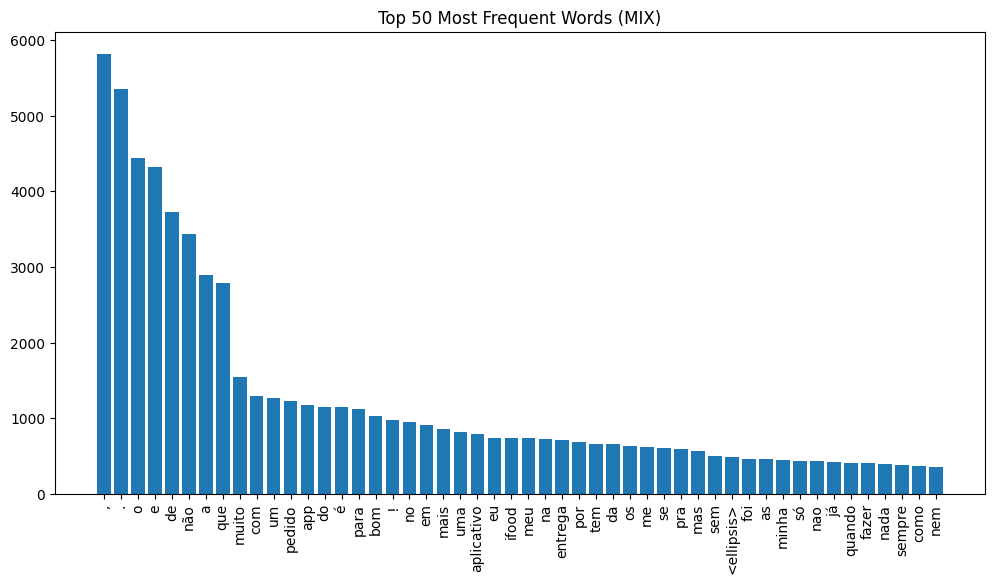

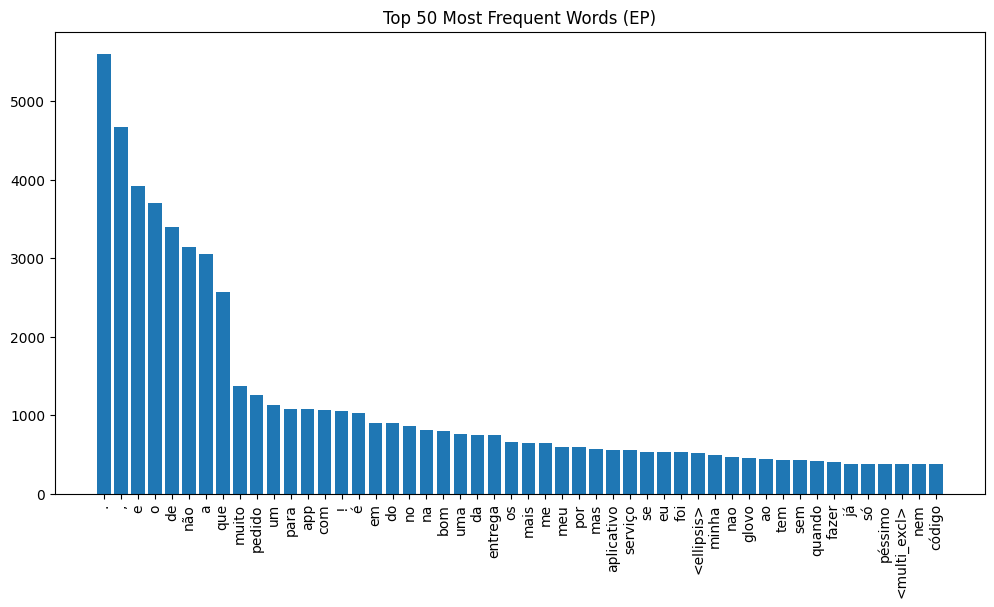

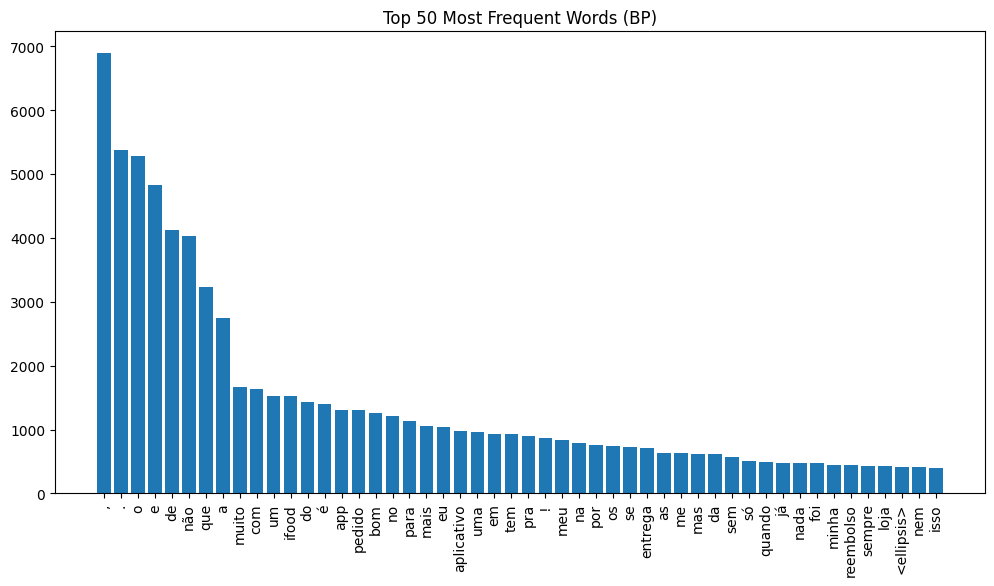

In [ ]:
def count_tokens_and_word_frequency(file):
    reviews = pd.read_excel(file, usecols=[0])
    list_of_reviews = reviews['review'].astype(str).tolist()
    all_reviews = ' '.join(list_of_reviews)
    tokens = tokenizer.tokenize(all_reviews)
    return set(token.lower() for token in tokens), FreqDist(token.lower() for token in tokens)


def plot_top_50(frequency, dataset_name):
    top_50 = frequency.most_common(50)

    # split into words + counts
    words = [w for w, c in top_50]
    counts = [c for w, c in top_50]

    # plot
    plt.figure(figsize=(12, 6))
    plt.bar(words, counts)
    plt.xticks(rotation=90)
    plt.title(f"Top 50 Most Frequent Words ({dataset_name})")
    plt.show()

mix_vocab ,frequency_mix = count_tokens_and_word_frequency("final_ds/MIX_dataset_no_singletons.xlsx")
ep_vocab ,frequency_ep = count_tokens_and_word_frequency("final_ds/EP_dataset_no_singletons.xlsx")
bp_vocab ,frequency_bp = count_tokens_and_word_frequency("final_ds/BP_dataset_no_singletons.xlsx")

plot_top_50(frequency_mix, 'MIX')
plot_top_50(frequency_ep, 'EP')
plot_top_50(frequency_bp, 'BP')

In [ ]:
bp_not_in_ep = bp_vocab - ep_vocab
ep_not_in_bp = ep_vocab - bp_vocab


print("EP vocab count | BP Vocab count | BP not in EP count | EP not in BP count")
print(f"{len(ep_vocab)}           | {len(bp_vocab)}           | {len(bp_not_in_ep)}               | {len(ep_not_in_bp)}")
print("-------------------------------------------------------------------------")
print(f"50 European-specific words: {list(ep_not_in_bp)[:50]}")
print("-------------------------------------------------------------------------")
print(f"50 Brazilian-specific words: {list(bp_not_in_ep)[:50]}")

EP vocab count | BP Vocab count | BP not in EP count | EP not in BP count
4022           | 4294           | 1712               | 1440
-------------------------------------------------------------------------
50 European-specific words: ['brequedosapp', 'cobravam', 'oportunidades', 'sitios', 'metem', 'largada', 'mega', 'constava', 'sitio', 'habitual', 'convosco', 'suporta', 'gratuito', 'alargar', 't', 'mandado', 'parabens', 'roubalheira', 'informarem', 'lamentavelmente', 'faliu', 'startup', 'instalo', 'assistentes', 'definir', 'aplicacao', 'pegue', 'reencomendar', 'soluções', 'adquiridos', 'oeste', 'efectuei', 'encomendar', 'aspecto', 'codigos', '2h30', 'mencionar', 'reportado', 'quiserem', 'icone', '2km', 'descubro', 'falham', 'porto', 'baixada', 'pensado', 'gozam', 'satisfazer', 'diminui', 'madeira']
-------------------------------------------------------------------------
50 Brazilian-specific words: ['publica', 'excluída', 'fake', 'quantas', 'bastasse', '08', 'faltaram', 'altíssimas

### 2.8. Splitting the datasets

In [ ]:
BP_dataset = pd.read_excel("final_ds/BP_dataset_no_singletons.xlsx", header=0, usecols=[0,1])
EP_dataset = pd.read_excel("final_ds/EP_dataset_no_singletons.xlsx", header=0, usecols=[0,1])
MIX_dataset = pd.read_excel("final_ds/MIX_dataset_no_singletons.xlsx", header=0, usecols=[0,1])

print(BP_dataset.head())
print(EP_dataset.head())
print(MIX_dataset.head())

                                              review sentiment
0  Cuidado , se seu cartão for e usado em compra ...       neg
1                       Muito spam como notificações       neg
2  Se precisar de assistência deles ferro <MULTI_...       neg
3  tá rolando o tempo todo uma mudança o valor fi...       neg
4                                          Ótimo app       pos
                                              review sentiment
0  Nada é perfeito , mas a GLOVO não presta , faz...       neg
1  Não consegui utilizar os cupons que tenho para...       neg
2  lixo muito lixoso <ELLIPSIS> quando não dá pau...       neg
3  Uma dificuldade pra conseguir pedir um lanche ...       neg
4    Muito bom . Recebi tudo com qualidade e rapidez       pos
                                              review sentiment
0                                            ladrões       neg
1  Muito bom ! recebi o pedido em pouco tempo . V...       pos
2  Fiz um pedido que disseram que so demorariam n...   

In [ ]:
def train_val_test_split(df):
    train, temp = train_test_split(
        df,
        test_size=0.30,
        stratify=df["sentiment"],
        random_state=seed
    )
    val, test = train_test_split(
        temp,
        test_size=1/3,
        stratify=temp["sentiment"],
        random_state=seed
    )
    return train.reset_index(drop=True), val.reset_index(drop=True), test.reset_index(drop=True)

In [ ]:
label_map = {
    "neg": 0,
    "pos": 1
}

datasets = {
    "BP": BP_dataset,
    "EP": EP_dataset,
    "MIX": MIX_dataset
}

splits = {}

for name, df in datasets.items():
    train, val, test = train_val_test_split(df)

    splits[name] = {
        "X_train": train["review"],
        "y_train": train["sentiment"].map(label_map).tolist(),
        "X_val": val["review"],
        "y_val": val["sentiment"].map(label_map).tolist(),
        "X_test": test["review"],
        "y_test": test["sentiment"].map(label_map).tolist()
    }

    print(name)
    print(len(train), len(val), len(test))
    print(train.head())

BP
4609 1317 659
                                              review sentiment
0                                        muito bom !       pos
1  recebi minha entrega gelada e amassada , fiz m...       neg
2  maravilhosa experiência sempre amooo nunca dec...       pos
3                                   prático e útil .       pos
4  Restaurante manda comida , marmita revirada se...       neg
EP
4593 1312 657
                                              review sentiment
0  Fiz o pedido , cobraram no meu cartão chegou o...       neg
1        Spam não me deixa nada que vem logo anúncio       neg
2                                          excelente       pos
3  Cadastrei o cupom de desconto e o desconto não...       neg
4                                            um lixo       neg
MIX
4600 1314 658
                                              review sentiment
0                             e muitas promoções boa       pos
1                               Muito rápido adoro !       pos
2  

In [ ]:
BP_X_train = splits["BP"]["X_train"]
BP_y_train = splits["BP"]["y_train"]

EP_X_test = splits["EP"]["X_test"]

MIX_y_val = splits["MIX"]["y_val"]


# sanity check: checking that labels have been converted to 1/0
print(BP_y_train[:10])

[1, 0, 1, 1, 0, 0, 1, 1, 1, 0]


In [ ]:
# visualising
print(BP_X_train[:10])
print(BP_y_train[:10])

0                                          muito bom !
1    recebi minha entrega gelada e amassada , fiz m...
2    maravilhosa experiência sempre amooo nunca dec...
3                                     prático e útil .
4    Restaurante manda comida , marmita revirada se...
5    lixo meu pai foi fazer um pedido de pizza e ro...
6    Melhor app , tudo top :rosto_sorridente_com_ol...
7                                 amo de coração o app
8                                                ótimo
9    FALHA NA PRESTAÇÃO DE SERVIÇO ! Não recebi meu...
Name: review, dtype: object
[1, 0, 1, 1, 0, 0, 1, 1, 1, 0]


# 3. Training the models

The predict_and_report() function will be used to make model predictions on the validation and test sets, and to report the metrics (Accuracy, F1, Precision, Recall, Confusion Matrix) of predictions.

In [ ]:
def predict_and_report(model, X, y, display=True):
    preds = model.predict(X)
    acc = accuracy_score(y, preds)
    f1 = f1_score(y, preds, average="macro") # macro average to treat pos and neg examples as eq. imp
    pr = precision_score(y, preds, average="macro")
    rec = recall_score(y, preds, average="macro")
    clf_report = classification_report(y, preds)
    cm = confusion_matrix(y, preds, labels=model.classes_)

    if display:
        print("Accuracy:", acc)
        print("F1-score:", f1)
        print("Precision:", pr)
        print("Recall:", rec)
        print(clf_report)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
        disp.plot(cmap="Blues")
        plt.show()
        plt.close()

    return preds, acc, f1, pr, rec, clf_report, cm

## 3.1. Training, validating and testing on a small subset (500 samples, BP-BP)

Validation results:
Accuracy: 0.916
F1-score: 0.9154589371980677
Precision: 0.9171717171717171
Recall: 0.9144921718185468
              precision    recall  f1-score   support

           0       0.91      0.94      0.92       265
           1       0.93      0.89      0.91       235

    accuracy                           0.92       500
   macro avg       0.92      0.91      0.92       500
weighted avg       0.92      0.92      0.92       500



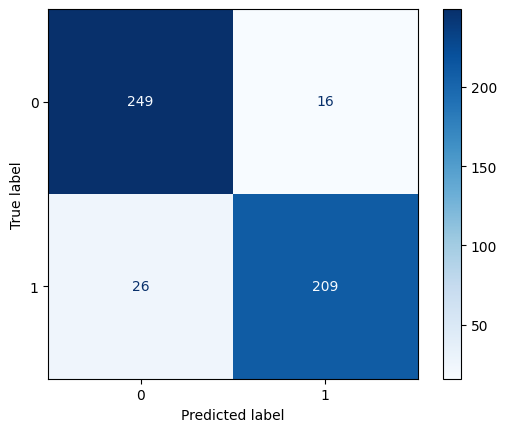

In [ ]:
# initialising the model and vectorizer
model = MultinomialNB()
# note for paper: since reviews are small, tfid should not improve accuracy by a lot really
vectorizer = CountVectorizer(
    token_pattern=r":\w+:|<[^>]+>|\b\w+\b|[.,!?]" # tokens will be split by breaks, <> or :: (single punctuation marks are also in)
)

# preparing the data
subset_size = 500
BP_X_train_sub = splits["BP"]["X_train"][:subset_size]
BP_y_train_sub = splits["BP"]["y_train"][:subset_size]
BP_X_val_sub = splits["BP"]["X_val"][:subset_size]
BP_y_val_sub = splits["BP"]["y_val"][:subset_size]
BP_X_test_sub = splits["BP"]["X_test"][:subset_size]
BP_y_test_sub = splits["BP"]["y_test"][:subset_size]


BP_X_train_sub_vec = vectorizer.fit_transform(BP_X_train_sub)
BP_X_val_sub_vec = vectorizer.transform(BP_X_val_sub)
BP_X_test_sub_vec = vectorizer.transform(BP_X_test_sub)

# train on BP
model.fit(BP_X_train_sub_vec, BP_y_train_sub)

# validate on BP
print("Validation results:")
val_preds_sub, val_acc_sub, val_f1_sub, val_pr_sub, val_rec_sub, val_clf_report_sub, val_cm_sub = predict_and_report(model, BP_X_val_sub_vec, BP_y_val_sub, display=True)

Test results:
Accuracy: 0.91
F1-score: 0.9094490882529308
Precision: 0.9170542635658915
Recall: 0.9089847000832214
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       254
           1       0.97      0.85      0.90       246

    accuracy                           0.91       500
   macro avg       0.92      0.91      0.91       500
weighted avg       0.92      0.91      0.91       500



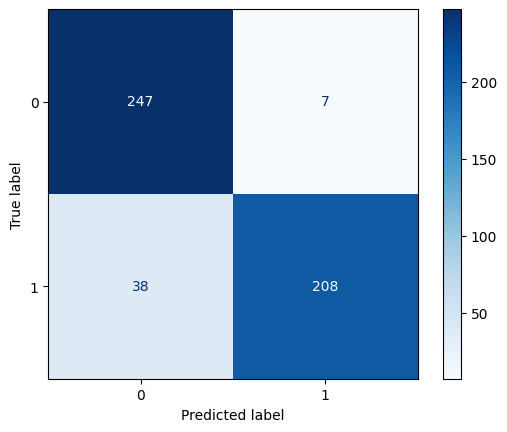

In [ ]:
# test on BP
print("Test results:")
test_preds_sub, test_acc_sub, test_f1_sub, test_pr_sub, test_rec_sub, test_clf_report_sub, test_cm_sub = predict_and_report(model, BP_X_test_sub_vec, BP_y_test_sub, display=True)

In [ ]:
# look into the validation misclassifications

# combine reviews, true labels, and predictions into one DataFrame
val_results = pd.DataFrame({
    "review": BP_X_val_sub,
    "true_sentiment": BP_y_val_sub,
    "predicted_sentiment": val_preds_sub
})

# filter only the misclassified reviews
misclassified = val_results[val_results["true_sentiment"] != val_results["predicted_sentiment"]]

print(f"Number of misclassified reviews: {len(misclassified)}")

pos_as_neg = misclassified[
    (misclassified["true_sentiment"] == 1) &
    (misclassified["predicted_sentiment"] == 0)
]

neg_as_pos = misclassified[
    (misclassified["true_sentiment"] == 0) &
    (misclassified["predicted_sentiment"] == 1)
]

print("Positive misclassified as negative:")
for idx, row in pos_as_neg.iterrows():
    print(f"Review {idx}:")
    print(f"Text: {row['review']}")
    print(f"True: {row['true_sentiment']}, Predicted: {row['predicted_sentiment']}")
    print("-" * 50)
print("------------------------------------------------------------------------")
print("Negative misclassified as positive:")
for idx, row in neg_as_pos.iterrows():
    print(f"Review {idx}:")
    print(f"Text: {row['review']}")
    print(f"True: {row['true_sentiment']}, Predicted: {row['predicted_sentiment']}")
    print("-" * 50)

Number of misclassified reviews: 42
Positive misclassified as negative:
Review 5:
Text: de mais
True: 1, Predicted: 0
--------------------------------------------------
Review 8:
Text: eu gostei preços baixo e entrega em casa
True: 1, Predicted: 0
--------------------------------------------------
Review 23:
Text: gosto bastante , só acho que poderia ser igual a Uber a gente poderia ver onde que tá vindo o motorista
True: 1, Predicted: 0
--------------------------------------------------
Review 28:
Text: tem várias promoções que em outros app de comida não tem e outra nunca tive problema em questão de entregador ou comida
True: 1, Predicted: 0
--------------------------------------------------
Review 31:
Text: Sempre me salva nas horas mais rs ! Nunca tive nenhum tipo de problema até agora . Muita das vezes , não estou disposto a cozinhar , então , faço um pedido pelo Ifood
True: 1, Predicted: 0
--------------------------------------------------
Review 64:
Text: Apenas gostaria que o i

## 3.2. Training, validating and testing all 3 statistical models across all 9 configurations.


RUNNING MODEL: LR

>>> VALIDATION: LR trained on BP
Accuracy: 0.9400151860288535
F1-score: 0.9399797515381043
Precision: 0.941215028901734
Recall: 0.9400754116507541
              precision    recall  f1-score   support

           0       0.96      0.91      0.94       660
           1       0.92      0.97      0.94       657

    accuracy                           0.94      1317
   macro avg       0.94      0.94      0.94      1317
weighted avg       0.94      0.94      0.94      1317



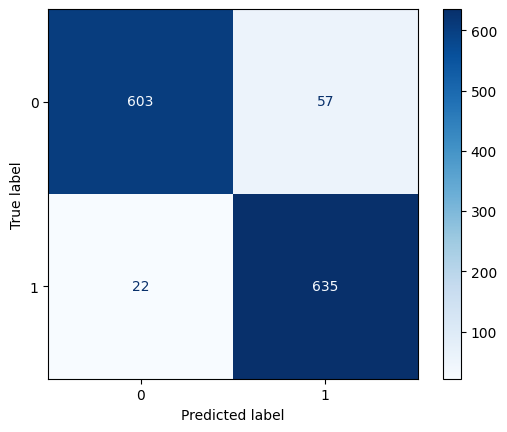

--- Configuration: Train=BP | Test=BP ---
Accuracy: 0.9317147192716236
F1-score: 0.931714090315628
Precision: 0.9317122593718339
Recall: 0.9317202122172279
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       331
           1       0.93      0.93      0.93       328

    accuracy                           0.93       659
   macro avg       0.93      0.93      0.93       659
weighted avg       0.93      0.93      0.93       659



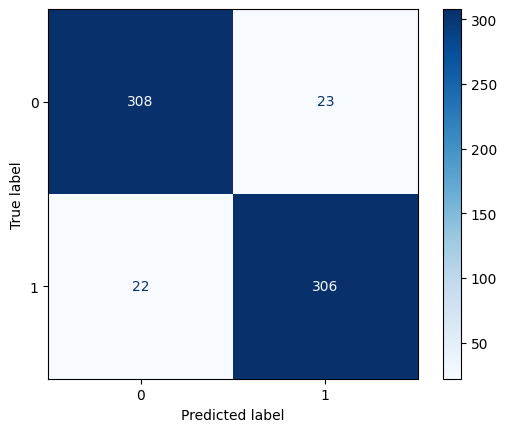

--- Configuration: Train=BP | Test=EP ---
Accuracy: 0.8949771689497716
F1-score: 0.8949294592922057
Precision: 0.8954628976576711
Recall: 0.8948985265499028
              precision    recall  f1-score   support

           0       0.88      0.91      0.90       330
           1       0.91      0.88      0.89       327

    accuracy                           0.89       657
   macro avg       0.90      0.89      0.89       657
weighted avg       0.90      0.89      0.89       657



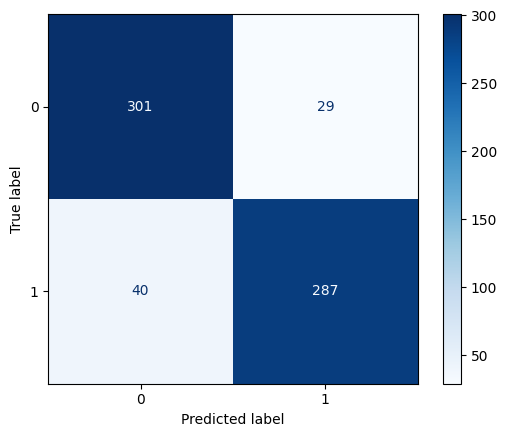

--- Configuration: Train=BP | Test=MIX ---
Accuracy: 0.9072948328267477
F1-score: 0.907294618708758
Precision: 0.9072948328267477
Recall: 0.9072985957132298
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       330
           1       0.91      0.91      0.91       328

    accuracy                           0.91       658
   macro avg       0.91      0.91      0.91       658
weighted avg       0.91      0.91      0.91       658



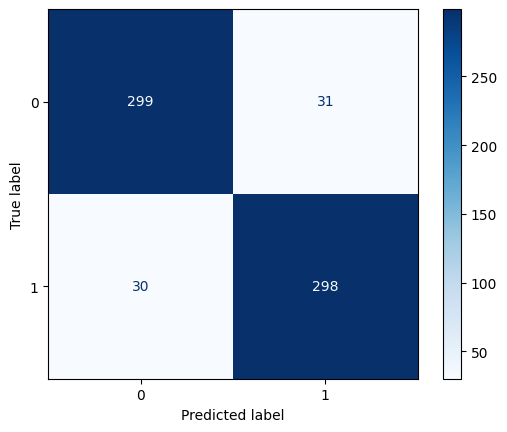


>>> VALIDATION: LR trained on EP
Accuracy: 0.9237804878048781
F1-score: 0.923779779333166
Precision: 0.9238531491771771
Recall: 0.92381375093824
              precision    recall  f1-score   support

           0       0.93      0.92      0.92       659
           1       0.92      0.93      0.92       653

    accuracy                           0.92      1312
   macro avg       0.92      0.92      0.92      1312
weighted avg       0.92      0.92      0.92      1312



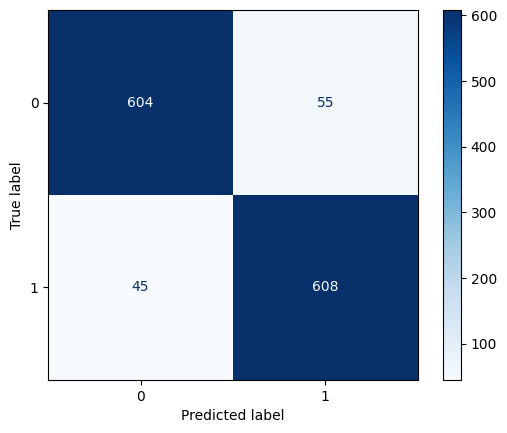

--- Configuration: Train=EP | Test=BP ---
Accuracy: 0.9028831562974203
F1-score: 0.9028829326701667
Precision: 0.902923621089864
Recall: 0.9029087760666126
              precision    recall  f1-score   support

           0       0.91      0.90      0.90       331
           1       0.90      0.91      0.90       328

    accuracy                           0.90       659
   macro avg       0.90      0.90      0.90       659
weighted avg       0.90      0.90      0.90       659



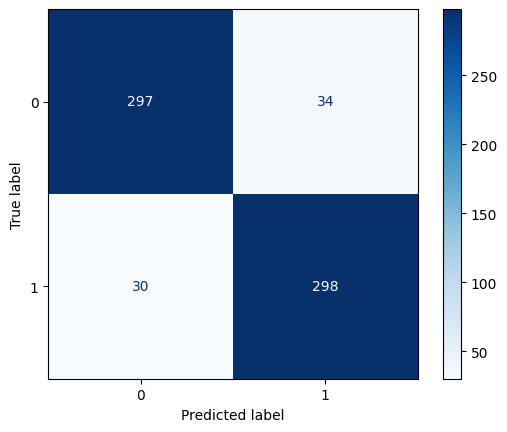

--- Configuration: Train=EP | Test=EP ---
Accuracy: 0.9117199391171994
F1-score: 0.9117197345985618
Precision: 0.9117611624932812
Recall: 0.9117458993605783
              precision    recall  f1-score   support

           0       0.92      0.91      0.91       330
           1       0.91      0.92      0.91       327

    accuracy                           0.91       657
   macro avg       0.91      0.91      0.91       657
weighted avg       0.91      0.91      0.91       657



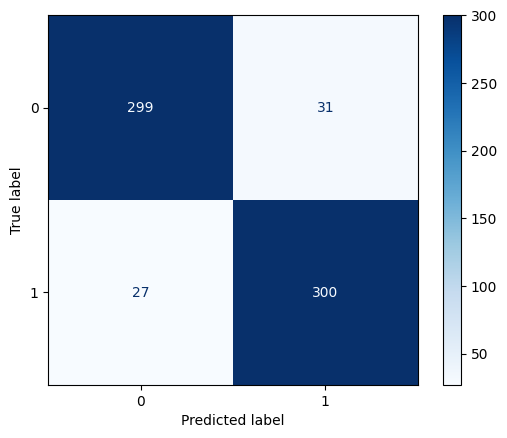

--- Configuration: Train=EP | Test=MIX ---
Accuracy: 0.9057750759878419
F1-score: 0.9057533081984179
Precision: 0.9062800591934888
Recall: 0.905829637841833
              precision    recall  f1-score   support

           0       0.92      0.89      0.90       330
           1       0.89      0.92      0.91       328

    accuracy                           0.91       658
   macro avg       0.91      0.91      0.91       658
weighted avg       0.91      0.91      0.91       658



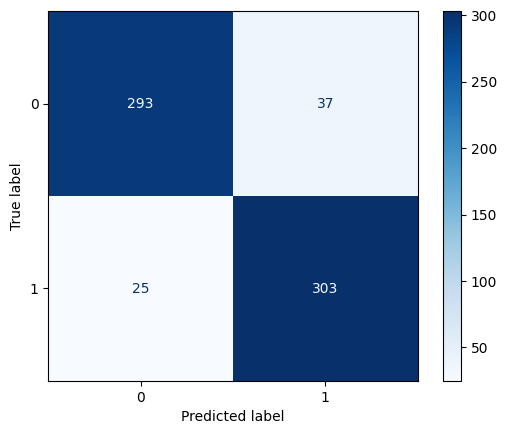


>>> VALIDATION: LR trained on MIX
Accuracy: 0.9322678843226788
F1-score: 0.9322647066489431
Precision: 0.9324538533736573
Recall: 0.9323185988323603
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       660
           1       0.92      0.94      0.93       654

    accuracy                           0.93      1314
   macro avg       0.93      0.93      0.93      1314
weighted avg       0.93      0.93      0.93      1314



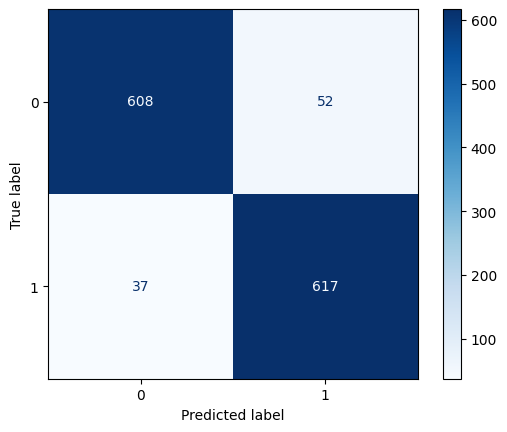

--- Configuration: Train=MIX | Test=BP ---
Accuracy: 0.9408194233687405
F1-score: 0.9408194233687405
Precision: 0.9408389212290914
Recall: 0.9408389212290914
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       331
           1       0.94      0.95      0.94       328

    accuracy                           0.94       659
   macro avg       0.94      0.94      0.94       659
weighted avg       0.94      0.94      0.94       659



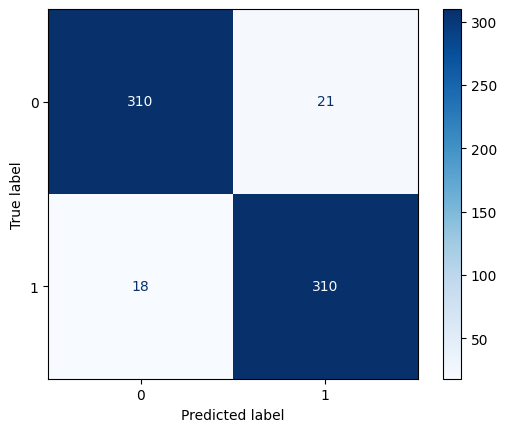

--- Configuration: Train=MIX | Test=EP ---
Accuracy: 0.9162861491628614
F1-score: 0.9162861491628614
Precision: 0.9163052543786488
Recall: 0.9163052543786488
              precision    recall  f1-score   support

           0       0.92      0.91      0.92       330
           1       0.91      0.92      0.92       327

    accuracy                           0.92       657
   macro avg       0.92      0.92      0.92       657
weighted avg       0.92      0.92      0.92       657



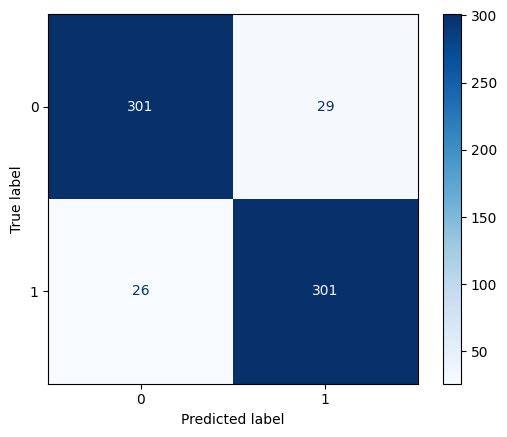

--- Configuration: Train=MIX | Test=MIX ---
Accuracy: 0.9240121580547113
F1-score: 0.9240114560236512
Precision: 0.9240114560236512
Recall: 0.9240114560236512
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       330
           1       0.92      0.92      0.92       328

    accuracy                           0.92       658
   macro avg       0.92      0.92      0.92       658
weighted avg       0.92      0.92      0.92       658



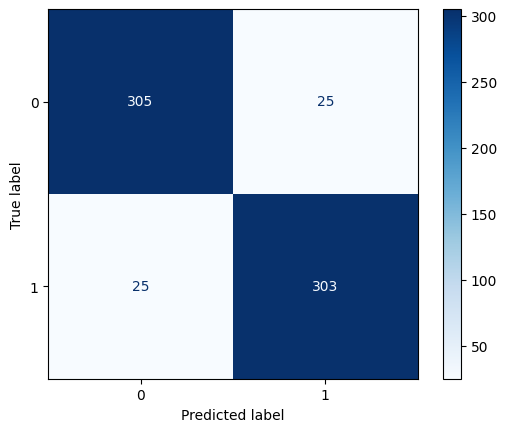


RUNNING MODEL: SVM

>>> VALIDATION: SVM trained on BP
Accuracy: 0.9347000759301443
F1-score: 0.9346638762108255
Precision: 0.93581788675023
Recall: 0.9347585443475854
              precision    recall  f1-score   support

           0       0.96      0.91      0.93       660
           1       0.91      0.96      0.94       657

    accuracy                           0.93      1317
   macro avg       0.94      0.93      0.93      1317
weighted avg       0.94      0.93      0.93      1317



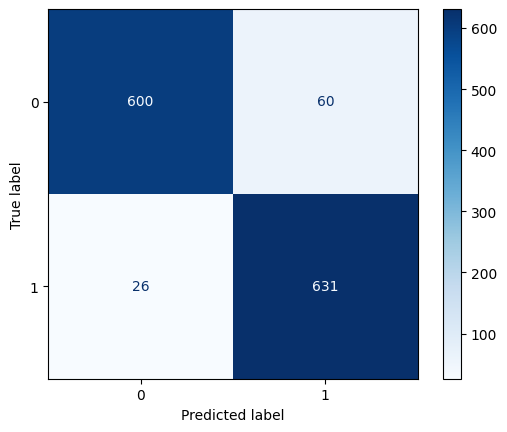

--- Configuration: Train=BP | Test=BP ---
Accuracy: 0.9317147192716236
F1-score: 0.931714090315628
Precision: 0.9317122593718339
Recall: 0.9317202122172279
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       331
           1       0.93      0.93      0.93       328

    accuracy                           0.93       659
   macro avg       0.93      0.93      0.93       659
weighted avg       0.93      0.93      0.93       659



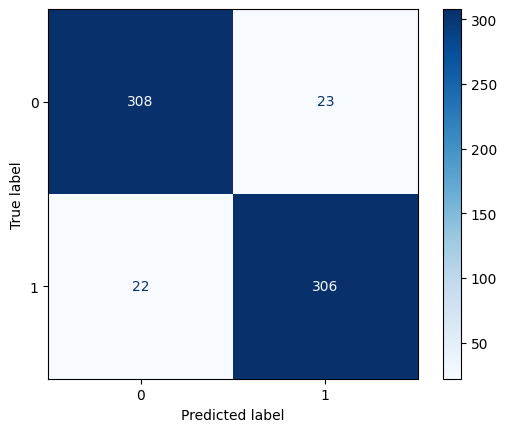

--- Configuration: Train=BP | Test=EP ---
Accuracy: 0.867579908675799
F1-score: 0.86753571801022
Precision: 0.8678827851060278
Recall: 0.8675145954962469
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       330
           1       0.88      0.85      0.87       327

    accuracy                           0.87       657
   macro avg       0.87      0.87      0.87       657
weighted avg       0.87      0.87      0.87       657



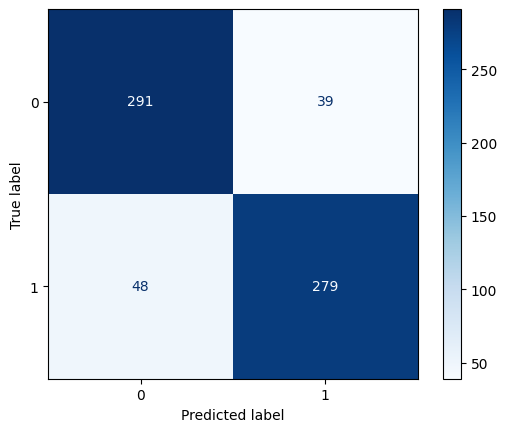

--- Configuration: Train=BP | Test=MIX ---
Accuracy: 0.9012158054711246
F1-score: 0.9012101011920848
Precision: 0.9012566412566412
Recall: 0.90120103473762
              precision    recall  f1-score   support

           0       0.90      0.91      0.90       330
           1       0.90      0.90      0.90       328

    accuracy                           0.90       658
   macro avg       0.90      0.90      0.90       658
weighted avg       0.90      0.90      0.90       658



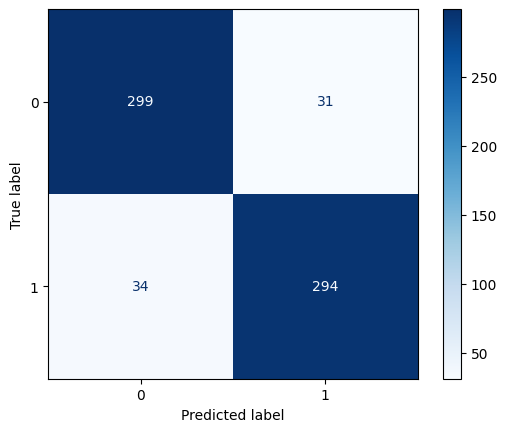


>>> VALIDATION: SVM trained on EP
Accuracy: 0.9077743902439024
F1-score: 0.9077550446459959
Precision: 0.9083103021505077
Recall: 0.9078596044403442
              precision    recall  f1-score   support

           0       0.92      0.89      0.91       659
           1       0.89      0.93      0.91       653

    accuracy                           0.91      1312
   macro avg       0.91      0.91      0.91      1312
weighted avg       0.91      0.91      0.91      1312



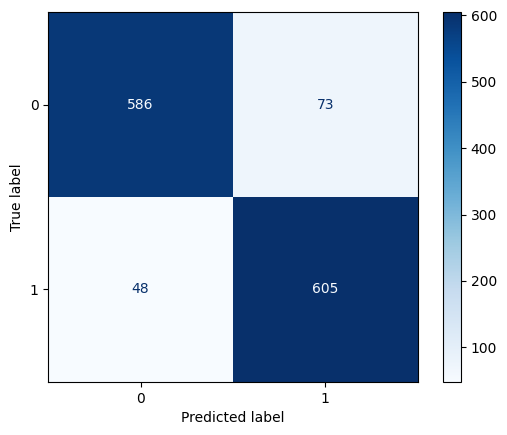

--- Configuration: Train=EP | Test=BP ---
Accuracy: 0.8968133535660091
F1-score: 0.8968112150910028
Precision: 0.896918470750806
Recall: 0.8968526637683296
              precision    recall  f1-score   support

           0       0.90      0.89      0.90       331
           1       0.89      0.91      0.90       328

    accuracy                           0.90       659
   macro avg       0.90      0.90      0.90       659
weighted avg       0.90      0.90      0.90       659



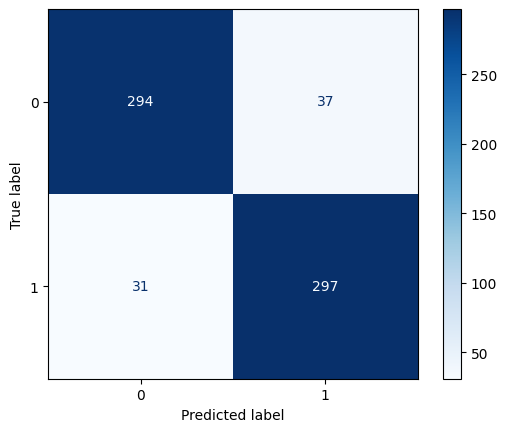

--- Configuration: Train=EP | Test=EP ---
Accuracy: 0.9056316590563166
F1-score: 0.9056209453197405
Precision: 0.9059625370919882
Recall: 0.9056991937725882
              precision    recall  f1-score   support

           0       0.92      0.89      0.90       330
           1       0.89      0.92      0.91       327

    accuracy                           0.91       657
   macro avg       0.91      0.91      0.91       657
weighted avg       0.91      0.91      0.91       657



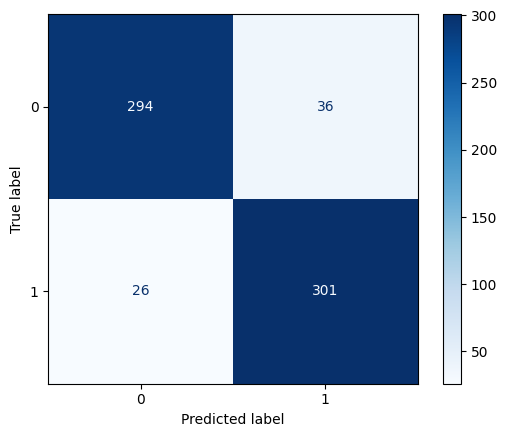

--- Configuration: Train=EP | Test=MIX ---
Accuracy: 0.8936170212765957
F1-score: 0.8935924447401493
Precision: 0.8941083980762117
Recall: 0.8936714708056172
              precision    recall  f1-score   support

           0       0.91      0.88      0.89       330
           1       0.88      0.91      0.90       328

    accuracy                           0.89       658
   macro avg       0.89      0.89      0.89       658
weighted avg       0.89      0.89      0.89       658



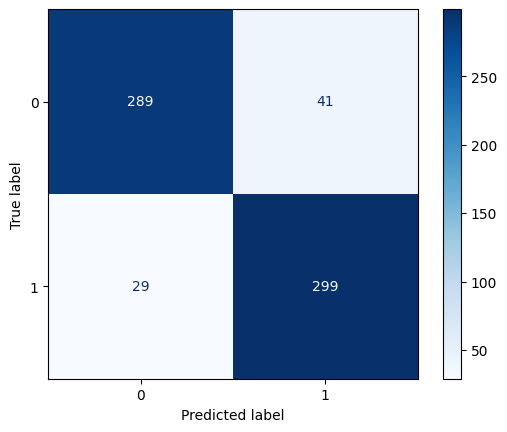


>>> VALIDATION: SVM trained on MIX
Accuracy: 0.9223744292237442
F1-score: 0.922372810675563
Precision: 0.922484984984985
Recall: 0.9224145120934112
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       660
           1       0.91      0.93      0.92       654

    accuracy                           0.92      1314
   macro avg       0.92      0.92      0.92      1314
weighted avg       0.92      0.92      0.92      1314



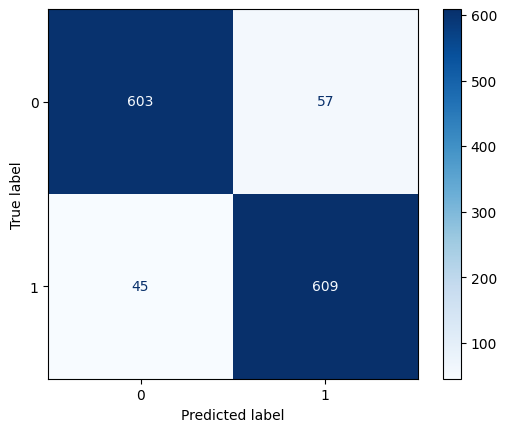

--- Configuration: Train=MIX | Test=BP ---
Accuracy: 0.936267071320182
F1-score: 0.936266924564797
Precision: 0.9363094580155484
Recall: 0.9362933829489353
              precision    recall  f1-score   support

           0       0.94      0.93      0.94       331
           1       0.93      0.94      0.94       328

    accuracy                           0.94       659
   macro avg       0.94      0.94      0.94       659
weighted avg       0.94      0.94      0.94       659



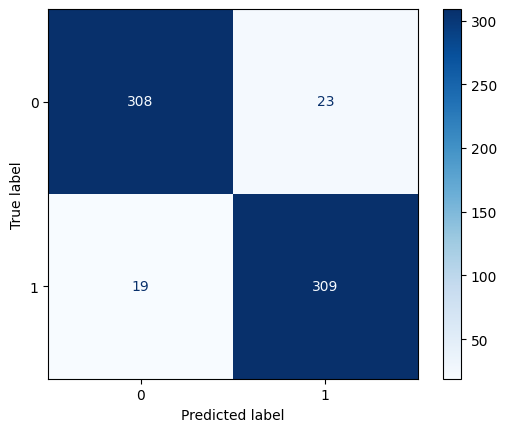

--- Configuration: Train=MIX | Test=EP ---
Accuracy: 0.9147640791476408
F1-score: 0.91476388168137
Precision: 0.9147685150863667
Recall: 0.9147762023908813
              precision    recall  f1-score   support

           0       0.92      0.91      0.91       330
           1       0.91      0.92      0.91       327

    accuracy                           0.91       657
   macro avg       0.91      0.91      0.91       657
weighted avg       0.91      0.91      0.91       657



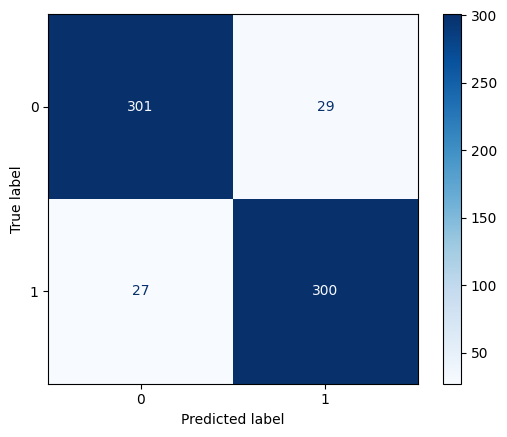

--- Configuration: Train=MIX | Test=MIX ---
Accuracy: 0.9088145896656535
F1-score: 0.9088011088011088
Precision: 0.9089673913043479
Recall: 0.9087860310421286
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       330
           1       0.92      0.90      0.91       328

    accuracy                           0.91       658
   macro avg       0.91      0.91      0.91       658
weighted avg       0.91      0.91      0.91       658



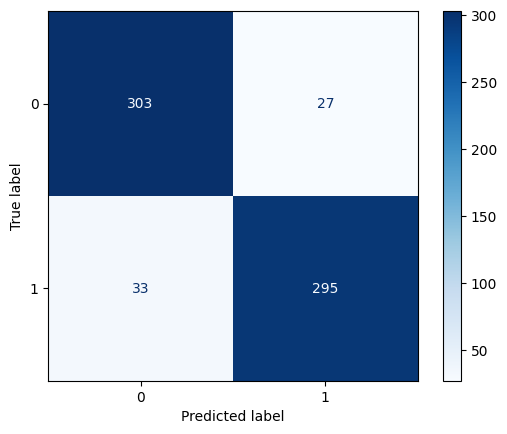


RUNNING MODEL: MNB

>>> VALIDATION: MNB trained on BP
Accuracy: 0.9460895975702354
F1-score: 0.9460884786154482
Precision: 0.9461026471280114
Recall: 0.9460841289608413
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       660
           1       0.95      0.94      0.95       657

    accuracy                           0.95      1317
   macro avg       0.95      0.95      0.95      1317
weighted avg       0.95      0.95      0.95      1317



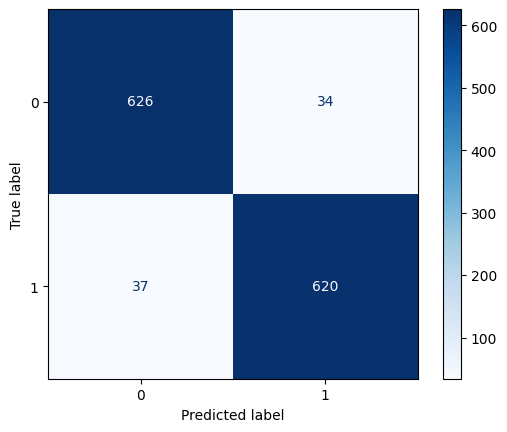

--- Configuration: Train=BP | Test=BP ---
Accuracy: 0.9408194233687405
F1-score: 0.9408057929757405
Precision: 0.9410542129808844
Recall: 0.9407698401002137
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       331
           1       0.95      0.93      0.94       328

    accuracy                           0.94       659
   macro avg       0.94      0.94      0.94       659
weighted avg       0.94      0.94      0.94       659



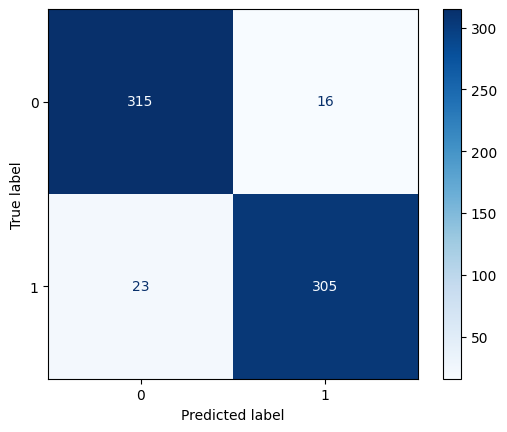

--- Configuration: Train=BP | Test=EP ---
Accuracy: 0.8584474885844748
F1-score: 0.8571755823330722
Precision: 0.8705972067682155
Recall: 0.8580344731720879
              precision    recall  f1-score   support

           0       0.80      0.95      0.87       330
           1       0.94      0.77      0.84       327

    accuracy                           0.86       657
   macro avg       0.87      0.86      0.86       657
weighted avg       0.87      0.86      0.86       657



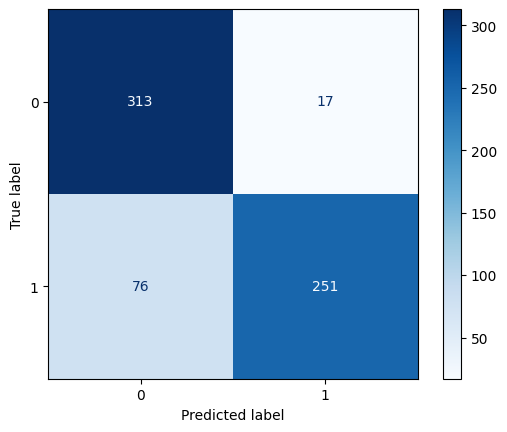

--- Configuration: Train=BP | Test=MIX ---
Accuracy: 0.898176291793313
F1-score: 0.897919536903039
Precision: 0.9018299336858894
Recall: 0.8980321507760531
              precision    recall  f1-score   support

           0       0.86      0.95      0.90       330
           1       0.94      0.85      0.89       328

    accuracy                           0.90       658
   macro avg       0.90      0.90      0.90       658
weighted avg       0.90      0.90      0.90       658



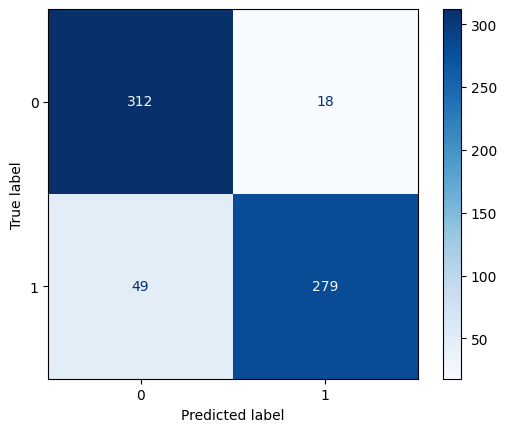


>>> VALIDATION: MNB trained on EP
Accuracy: 0.9275914634146342
F1-score: 0.9275607849518922
Precision: 0.9280807892777364
Recall: 0.9275167488909597
              precision    recall  f1-score   support

           0       0.91      0.94      0.93       659
           1       0.94      0.91      0.93       653

    accuracy                           0.93      1312
   macro avg       0.93      0.93      0.93      1312
weighted avg       0.93      0.93      0.93      1312



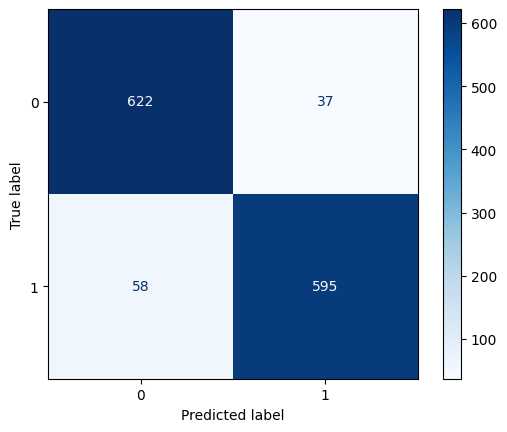

--- Configuration: Train=EP | Test=BP ---
Accuracy: 0.9241274658573596
F1-score: 0.9240181157415095
Precision: 0.9261326815901054
Recall: 0.9239739149657358
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       331
           1       0.95      0.89      0.92       328

    accuracy                           0.92       659
   macro avg       0.93      0.92      0.92       659
weighted avg       0.93      0.92      0.92       659



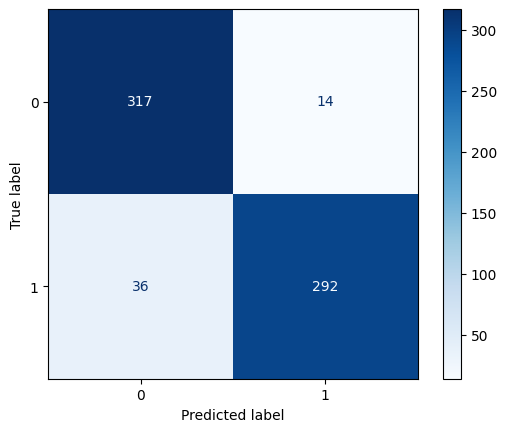

--- Configuration: Train=EP | Test=EP ---
Accuracy: 0.91324200913242
F1-score: 0.9130357039187228
Precision: 0.9166214877269073
Recall: 0.9130386433138726
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       330
           1       0.95      0.87      0.91       327

    accuracy                           0.91       657
   macro avg       0.92      0.91      0.91       657
weighted avg       0.92      0.91      0.91       657



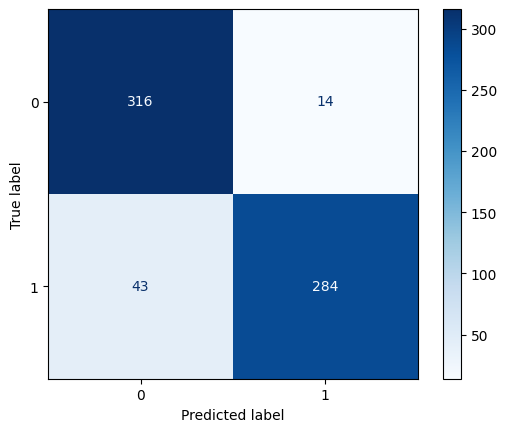

--- Configuration: Train=EP | Test=MIX ---
Accuracy: 0.9164133738601824
F1-score: 0.9162723981167652
Precision: 0.9189094965834612
Recall: 0.9162971175166297
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       330
           1       0.95      0.88      0.91       328

    accuracy                           0.92       658
   macro avg       0.92      0.92      0.92       658
weighted avg       0.92      0.92      0.92       658



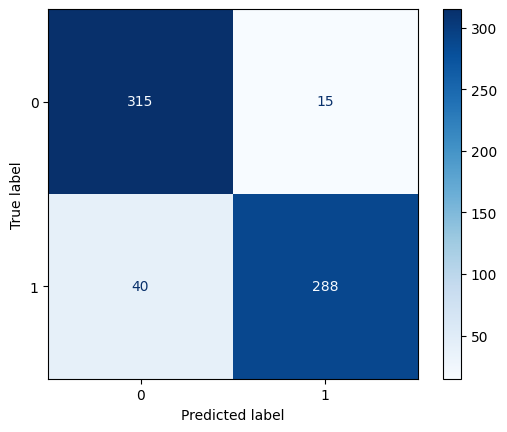


>>> VALIDATION: MNB trained on MIX
Accuracy: 0.9299847792998478
F1-score: 0.9299198374952753
Precision: 0.931223854234452
Recall: 0.9298651654156241
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       660
           1       0.95      0.90      0.93       654

    accuracy                           0.93      1314
   macro avg       0.93      0.93      0.93      1314
weighted avg       0.93      0.93      0.93      1314



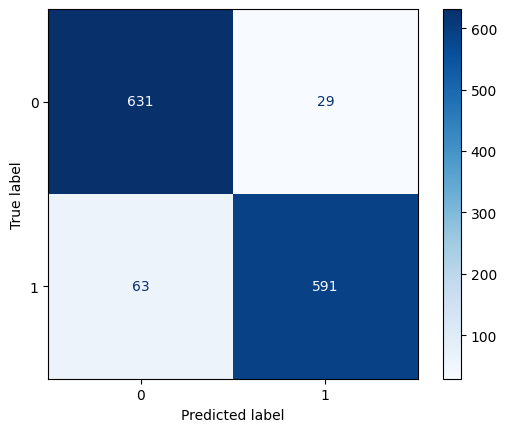

--- Configuration: Train=MIX | Test=BP ---
Accuracy: 0.9301972685887708
F1-score: 0.9300966664821886
Precision: 0.9322335166361162
Recall: 0.9300438434897944
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       331
           1       0.96      0.90      0.93       328

    accuracy                           0.93       659
   macro avg       0.93      0.93      0.93       659
weighted avg       0.93      0.93      0.93       659



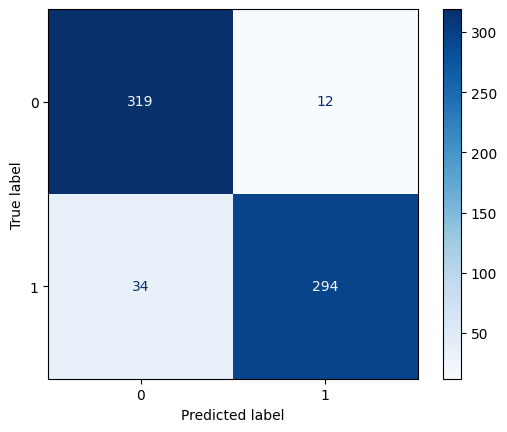

--- Configuration: Train=MIX | Test=EP ---
Accuracy: 0.9101978691019786
F1-score: 0.9099274316665621
Precision: 0.9145302749198854
Recall: 0.9099666388657215
              precision    recall  f1-score   support

           0       0.87      0.96      0.91       330
           1       0.96      0.86      0.90       327

    accuracy                           0.91       657
   macro avg       0.91      0.91      0.91       657
weighted avg       0.91      0.91      0.91       657



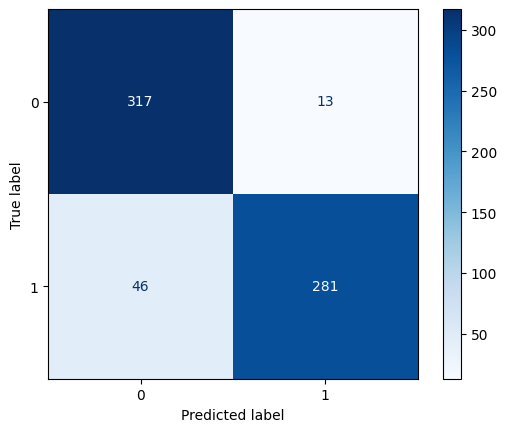

--- Configuration: Train=MIX | Test=MIX ---
Accuracy: 0.9164133738601824
F1-score: 0.9163281490232889
Precision: 0.9178651904192283
Recall: 0.9163248337028824
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       330
           1       0.94      0.89      0.91       328

    accuracy                           0.92       658
   macro avg       0.92      0.92      0.92       658
weighted avg       0.92      0.92      0.92       658



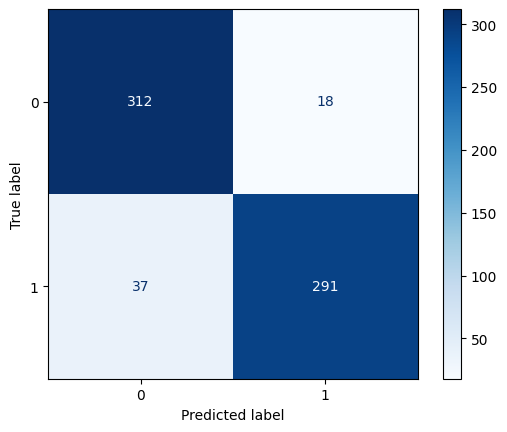


Final Results Summary:
   Model Train_Lang Test_Lang  Accuracy        F1  Precision    Recall
0     LR         BP        BP  0.931715  0.931714   0.931712  0.931720
1     LR         BP        EP  0.894977  0.894929   0.895463  0.894899
2     LR         BP       MIX  0.907295  0.907295   0.907295  0.907299
3     LR         EP        BP  0.902883  0.902883   0.902924  0.902909
4     LR         EP        EP  0.911720  0.911720   0.911761  0.911746
5     LR         EP       MIX  0.905775  0.905753   0.906280  0.905830
6     LR        MIX        BP  0.940819  0.940819   0.940839  0.940839
7     LR        MIX        EP  0.916286  0.916286   0.916305  0.916305
8     LR        MIX       MIX  0.924012  0.924011   0.924011  0.924011
9    SVM         BP        BP  0.931715  0.931714   0.931712  0.931720
10   SVM         BP        EP  0.867580  0.867536   0.867883  0.867515
11   SVM         BP       MIX  0.901216  0.901210   0.901257  0.901201
12   SVM         EP        BP  0.896813  0.896811   0

In [ ]:
# configuring variables
datasets = ["BP", "EP", "MIX"]
models_to_run = {
    "LR": LogisticRegression(random_state=seed, max_iter=1000),
    "SVM": LinearSVC(random_state=seed, max_iter=1000),
    "MNB": MultinomialNB()
}
token_pattern = r":\w+:|<[^>]+>|\b\w+\b|[.,!?]"

all_results = []

# these will be used when feeding reviews into the dialect classifier
cross_eval_records = []

# a triple loop to train the model, validate it and test it across dialects
for model_name, model_obj in models_to_run.items():
    print(f"\n{'='*30}\nRUNNING MODEL: {model_name}\n{'='*30}")

    for train_lang in datasets:
        # initialising a new vectorizer for the training set
        vectorizer = CountVectorizer(token_pattern=token_pattern)

        # preparing training data
        X_train_vec = vectorizer.fit_transform(splits[train_lang]["X_train"])
        y_train = splits[train_lang]["y_train"]

        # training the model
        model_obj.fit(X_train_vec, y_train)

        # validating the model on the same language we trained on
        print(f"\n>>> VALIDATION: {model_name} trained on {train_lang}")

        X_val_vec = vectorizer.transform(splits[train_lang]["X_val"])
        y_val = splits[train_lang]["y_val"]

        val_res = predict_and_report(model_obj, X_val_vec, y_val, display=True)

        for test_lang in datasets:
            print(f"--- Configuration: Train={train_lang} | Test={test_lang} ---")

            # prepare test data
            X_test_vec = vectorizer.transform(splits[test_lang]["X_test"])
            y_test = splits[test_lang]["y_test"]

            res = predict_and_report(model_obj, X_test_vec, y_test, display=True)

            y_pred = res[0]

            if train_lang != test_lang and train_lang in ["BP", "EP"] and test_lang in ["BP", "EP"]:
                for review, true, pred in zip(
                    splits[test_lang]["X_test"], y_test, y_pred
                ):
                    if true != pred:
                      if train_lang == "BP" and test_lang == "EP":
                        direction = "BP-EP"
                      else:
                        direction = "EP-BP"
                      cross_eval_records.append((review, test_lang, direction, true, pred))

            # storing data for a final summary table
            all_results.append({
                "Model": model_name,
                "Train_Lang": train_lang,
                "Test_Lang": test_lang,
                "Accuracy": res[1],
                "F1": res[2],
                "Precision": res[3],
                "Recall": res[4]
            })

# outputting comparison table
summary_df = pd.DataFrame(all_results)
print("\nFinal Results Summary:")
print(summary_df.to_string())

## 3.3. Training, validating and testing all 3 Transformer-based models across all 9 configurations.

The below will be used by all 3 models.

In [ ]:
set_seed(seed)

def predict_and_report_hf(trainer, dataset, display=True, label_names=None):
    outputs = trainer.predict(dataset)

    preds = np.argmax(outputs.predictions, axis=1)
    y_true = outputs.label_ids

    acc = accuracy_score(y_true, preds)
    f1 = f1_score(y_true, preds, average="macro")
    pr = precision_score(y_true, preds, average="macro")
    rec = recall_score(y_true, preds, average="macro")

    clf_report = classification_report(y_true, preds, target_names=label_names)
    cm = confusion_matrix(y_true, preds)

    if display:
        print("Accuracy:", acc)
        print("F1-score:", f1)
        print("Precision:", pr)
        print("Recall:", rec)
        print(clf_report)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
        disp.plot(cmap="Blues")
        plt.show()
        plt.close()

    return preds, acc, f1, pr, rec, clf_report, cm



In [ ]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
# function to extract all emojis in the datasets, so as to add them to the tokeniser
def extract_emoji_tokens(texts):
    tokens = set()
    pattern = r":([^\s][^:]*):"

    for text in texts:
        matches = re.findall(pattern, text)
        for m in matches:
            tokens.add(f":{m}:")

    return list(tokens)

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds)
    }


########################################
STARTING MODEL: Bertimbau
########################################

--- Training Bertimbau on BP ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. C

Epoch,Training Loss,Validation Loss,Accuracy
1,0.168688,0.136786,0.968869
2,0.071231,0.157053,0.966591
3,0.054724,0.148729,0.971906


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Testing Bertimbau (Train=BP) on Test=BP


Accuracy: 0.9696509863429439
F1-score: 0.9696492391584688
Precision: 0.9696798025018885
Recall: 0.9696365411539312
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       331
           1       0.97      0.97      0.97       328

    accuracy                           0.97       659
   macro avg       0.97      0.97      0.97       659
weighted avg       0.97      0.97      0.97       659



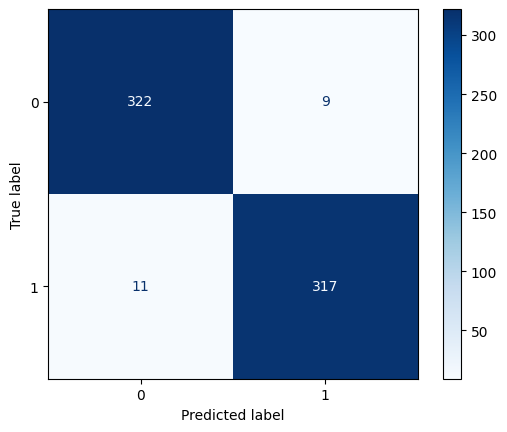

Testing Bertimbau (Train=BP) on Test=EP


Accuracy: 0.9101978691019786
F1-score: 0.9100344655518551
Precision: 0.9126993750582968
Recall: 0.9100222407561858
              precision    recall  f1-score   support

           0       0.88      0.95      0.91       330
           1       0.94      0.87      0.91       327

    accuracy                           0.91       657
   macro avg       0.91      0.91      0.91       657
weighted avg       0.91      0.91      0.91       657



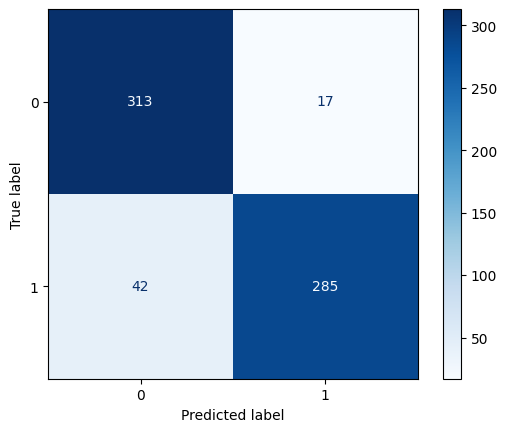

Testing Bertimbau (Train=BP) on Test=MIX


Accuracy: 0.9498480243161094
F1-score: 0.9498284407167366
Precision: 0.9503917777551643
Recall: 0.9497967479674797
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       330
           1       0.97      0.93      0.95       328

    accuracy                           0.95       658
   macro avg       0.95      0.95      0.95       658
weighted avg       0.95      0.95      0.95       658



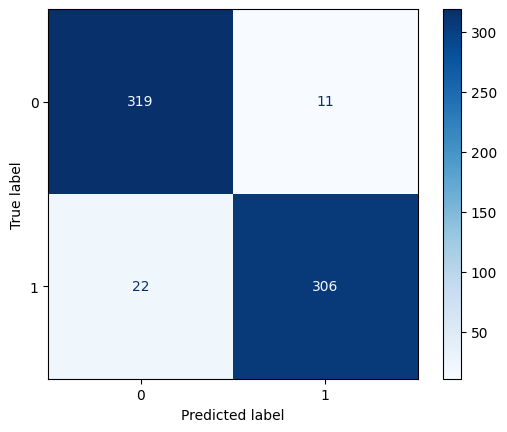

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


--- Training Bertimbau on EP ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. C

Epoch,Training Loss,Validation Loss,Accuracy
1,0.265791,0.197668,0.949695
2,0.126857,0.265012,0.948171
3,0.074914,0.276391,0.950457


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Testing Bertimbau (Train=EP) on Test=BP


Accuracy: 0.9559939301972686
F1-score: 0.9559837947768326
Precision: 0.9562388246787958
Recall: 0.9559446614103604
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       331
           1       0.97      0.95      0.96       328

    accuracy                           0.96       659
   macro avg       0.96      0.96      0.96       659
weighted avg       0.96      0.96      0.96       659



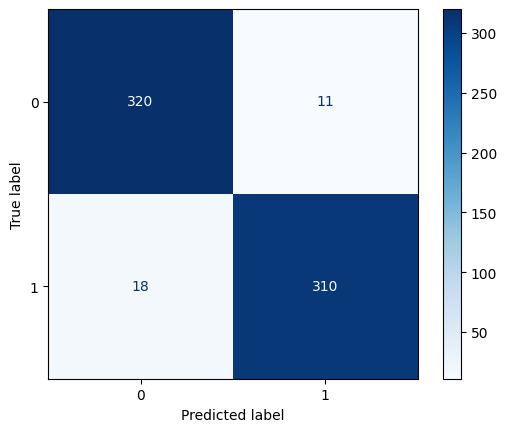

Testing Bertimbau (Train=EP) on Test=EP


Accuracy: 0.9467275494672754
F1-score: 0.9467255747359447
Precision: 0.9467360480418141
Recall: 0.9467194884626078
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       330
           1       0.95      0.94      0.95       327

    accuracy                           0.95       657
   macro avg       0.95      0.95      0.95       657
weighted avg       0.95      0.95      0.95       657



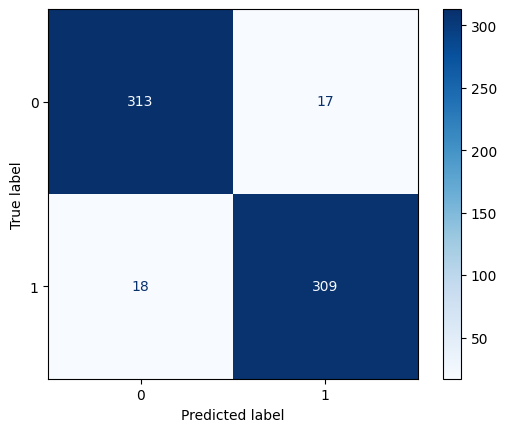

Testing Bertimbau (Train=EP) on Test=MIX


Accuracy: 0.9635258358662614
F1-score: 0.9635228028679134
Precision: 0.9636098174022325
Recall: 0.9635070214338507
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       330
           1       0.97      0.96      0.96       328

    accuracy                           0.96       658
   macro avg       0.96      0.96      0.96       658
weighted avg       0.96      0.96      0.96       658



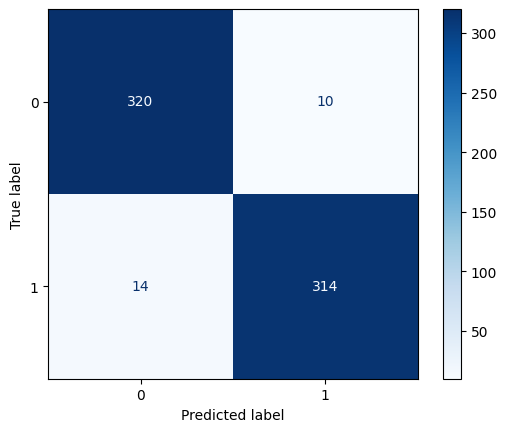

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


--- Training Bertimbau on MIX ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. C

Epoch,Training Loss,Validation Loss,Accuracy
1,0.220291,0.170000,0.955860
2,0.111505,0.168420,0.961948
3,0.052043,0.194716,0.963470


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Testing Bertimbau (Train=MIX) on Test=BP


Accuracy: 0.9696509863429439
F1-score: 0.9696453247351451
Precision: 0.9698426009547155
Recall: 0.96960890870238
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       331
           1       0.98      0.96      0.97       328

    accuracy                           0.97       659
   macro avg       0.97      0.97      0.97       659
weighted avg       0.97      0.97      0.97       659



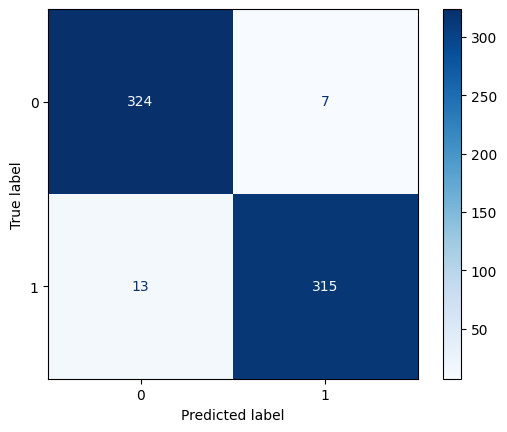

Testing Bertimbau (Train=MIX) on Test=EP


Accuracy: 0.9528158295281582
F1-score: 0.9528048958519195
Precision: 0.9530600890207716
Recall: 0.9527661940505977
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       330
           1       0.96      0.94      0.95       327

    accuracy                           0.95       657
   macro avg       0.95      0.95      0.95       657
weighted avg       0.95      0.95      0.95       657



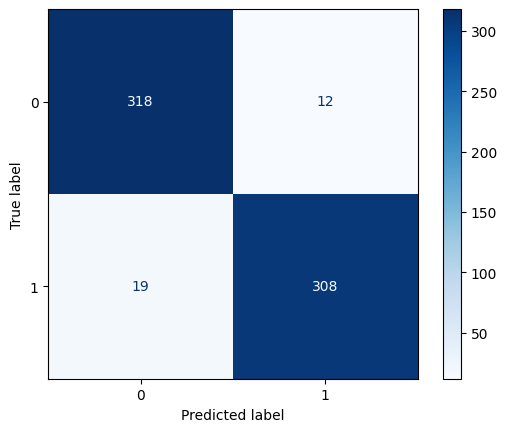

Testing Bertimbau (Train=MIX) on Test=MIX


Accuracy: 0.958966565349544
F1-score: 0.9589619209313607
Precision: 0.9590915392079848
Recall: 0.9589430894308943
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       330
           1       0.97      0.95      0.96       328

    accuracy                           0.96       658
   macro avg       0.96      0.96      0.96       658
weighted avg       0.96      0.96      0.96       658



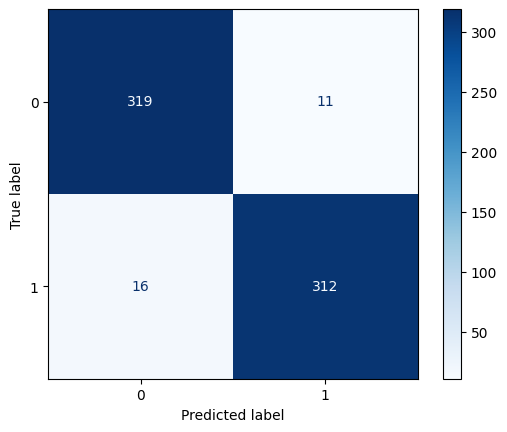

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


########################################
STARTING MODEL: Albertina
########################################


config.json:   0%|          | 0.00/779 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

Testing Albertina (Train=BP) on Test=BP


Accuracy: 0.9499241274658573
F1-score: 0.9499199760503862
Precision: 0.9499769691386458
Recall: 0.9499023653378528
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       331
           1       0.95      0.95      0.95       328

    accuracy                           0.95       659
   macro avg       0.95      0.95      0.95       659
weighted avg       0.95      0.95      0.95       659



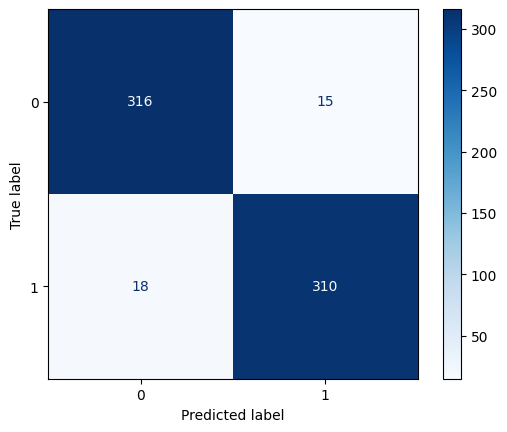

Testing Albertina (Train=BP) on Test=EP


Accuracy: 0.9117199391171994
F1-score: 0.9115229586150531
Precision: 0.9148605220380785
Recall: 0.9115234917987212
              precision    recall  f1-score   support

           0       0.88      0.95      0.92       330
           1       0.95      0.87      0.91       327

    accuracy                           0.91       657
   macro avg       0.91      0.91      0.91       657
weighted avg       0.91      0.91      0.91       657



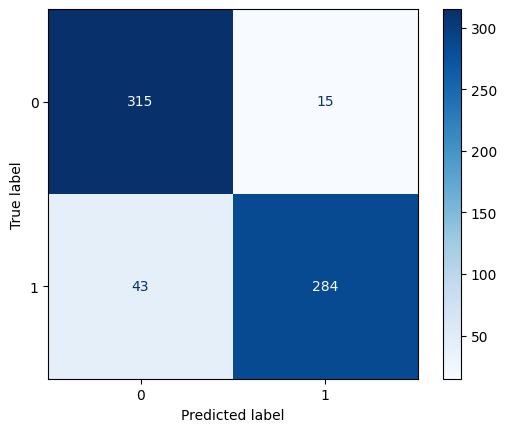

Testing Albertina (Train=BP) on Test=MIX


Accuracy: 0.9437689969604863
F1-score: 0.9437470395914924
Precision: 0.9443046523030241
Recall: 0.9437176644493718
              precision    recall  f1-score   support

           0       0.93      0.96      0.94       330
           1       0.96      0.93      0.94       328

    accuracy                           0.94       658
   macro avg       0.94      0.94      0.94       658
weighted avg       0.94      0.94      0.94       658



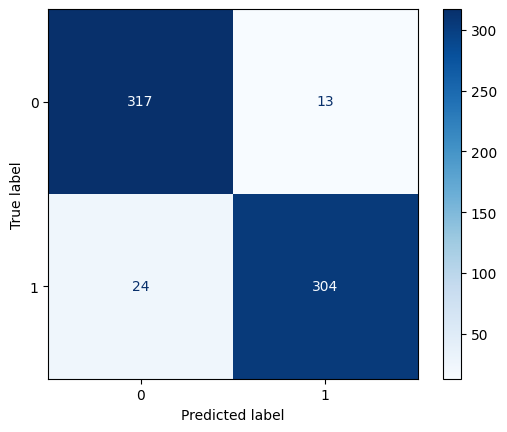

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


--- Training Albertina on EP ---


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

DebertaForSequenceClassification LOAD REPORT from: PORTULAN/albertina-ptpt-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
deberta.embeddings.position_ids            | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

Epoch,Training Loss,Validation Loss,Accuracy
1,0.344551,0.270484,0.931402
2,0.211983,0.266547,0.947409
3,0.129289,0.287918,0.944360


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

Testing Albertina (Train=EP) on Test=BP


Accuracy: 0.9393019726858877
F1-score: 0.9392850562004791
Precision: 0.9396017699115045
Recall: 0.9392454498563112
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       331
           1       0.95      0.93      0.94       328

    accuracy                           0.94       659
   macro avg       0.94      0.94      0.94       659
weighted avg       0.94      0.94      0.94       659



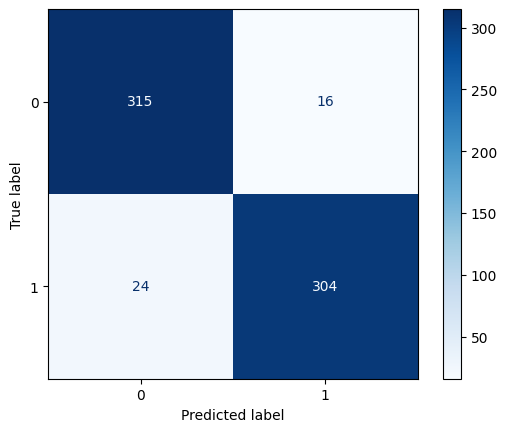

Testing Albertina (Train=EP) on Test=EP


Accuracy: 0.9497716894977168
F1-score: 0.94976750005213
Precision: 0.9498248248248249
Recall: 0.9497497914929107
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       330
           1       0.95      0.94      0.95       327

    accuracy                           0.95       657
   macro avg       0.95      0.95      0.95       657
weighted avg       0.95      0.95      0.95       657



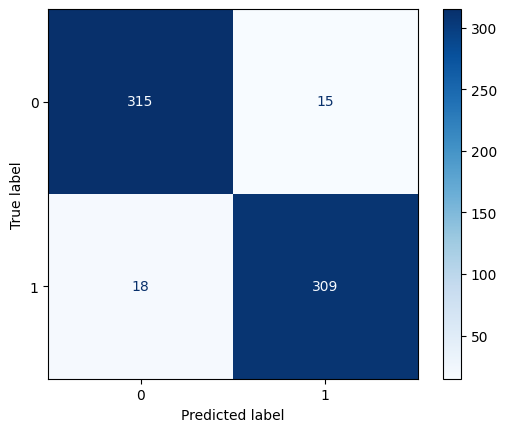

Testing Albertina (Train=EP) on Test=MIX


Accuracy: 0.9544072948328267
F1-score: 0.9544005544005545
Precision: 0.9545807453416149
Recall: 0.9543791574279379
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       330
           1       0.96      0.95      0.95       328

    accuracy                           0.95       658
   macro avg       0.95      0.95      0.95       658
weighted avg       0.95      0.95      0.95       658



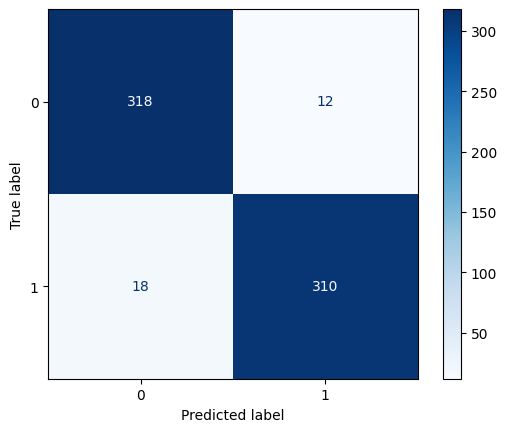

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


--- Training Albertina on MIX ---


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

DebertaForSequenceClassification LOAD REPORT from: PORTULAN/albertina-ptpt-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
deberta.embeddings.position_ids            | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

Epoch,Training Loss,Validation Loss,Accuracy
1,0.306863,0.218524,0.949011
2,0.176975,0.171762,0.960426
3,0.093182,0.220145,0.955099


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

Testing Albertina (Train=MIX) on Test=BP


Accuracy: 0.9590288315629742
F1-score: 0.9590227927510899
Precision: 0.9591626124133864
Recall: 0.9589934418981652
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       331
           1       0.97      0.95      0.96       328

    accuracy                           0.96       659
   macro avg       0.96      0.96      0.96       659
weighted avg       0.96      0.96      0.96       659



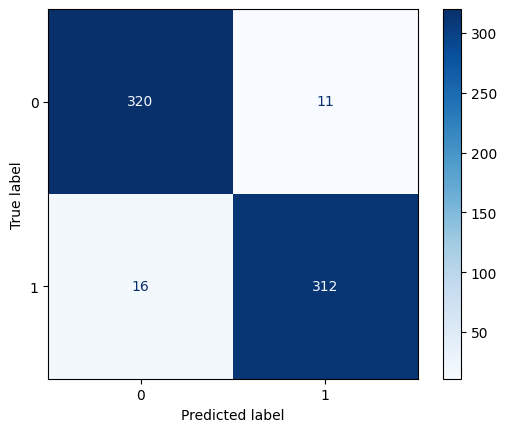

Testing Albertina (Train=MIX) on Test=EP


Accuracy: 0.9467275494672754
F1-score: 0.9467196496634498
Precision: 0.9468573282655048
Recall: 0.9466916875173756
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       330
           1       0.95      0.94      0.95       327

    accuracy                           0.95       657
   macro avg       0.95      0.95      0.95       657
weighted avg       0.95      0.95      0.95       657



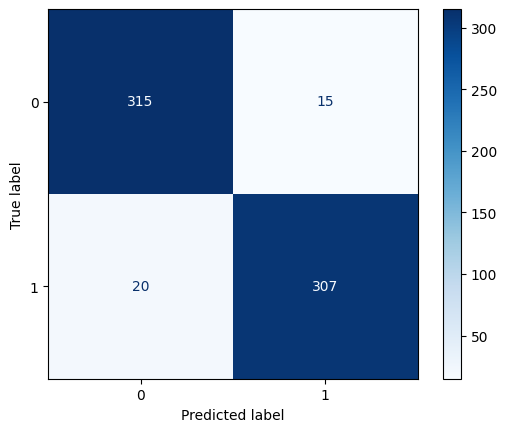

Testing Albertina (Train=MIX) on Test=MIX


Accuracy: 0.9544072948328267
F1-score: 0.9543803211403533
Precision: 0.9552844023107687
Recall: 0.9543422025129342
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       330
           1       0.97      0.93      0.95       328

    accuracy                           0.95       658
   macro avg       0.96      0.95      0.95       658
weighted avg       0.96      0.95      0.95       658



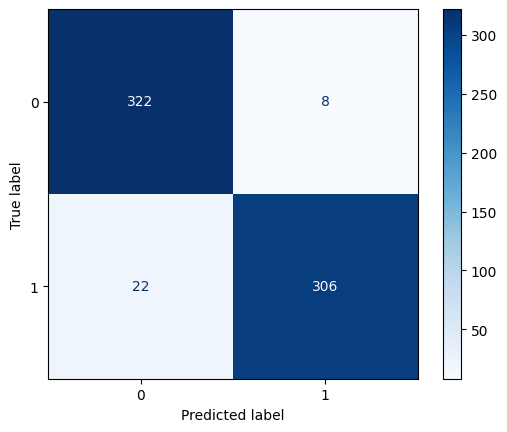

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


########################################
STARTING MODEL: XLM-R
########################################


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Testing XLM-R (Train=BP) on Test=BP


Accuracy: 0.9635811836115327
F1-score: 0.9635710337202874
Precision: 0.9639011799410029
Recall: 0.9635251639525458
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       331
           1       0.97      0.95      0.96       328

    accuracy                           0.96       659
   macro avg       0.96      0.96      0.96       659
weighted avg       0.96      0.96      0.96       659



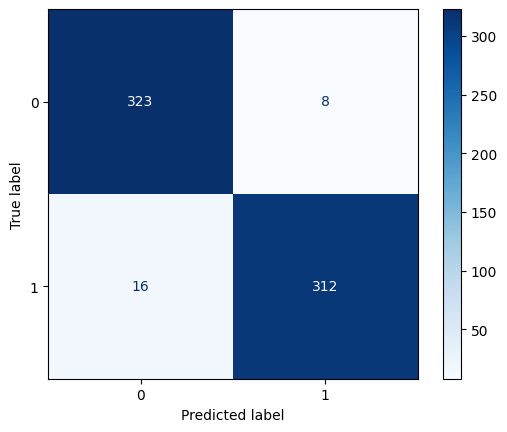

Testing XLM-R (Train=BP) on Test=EP


Accuracy: 0.9178082191780822
F1-score: 0.9175175761633747
Precision: 0.9230606726381612
Recall: 0.9175562969140951
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       330
           1       0.97      0.86      0.91       327

    accuracy                           0.92       657
   macro avg       0.92      0.92      0.92       657
weighted avg       0.92      0.92      0.92       657



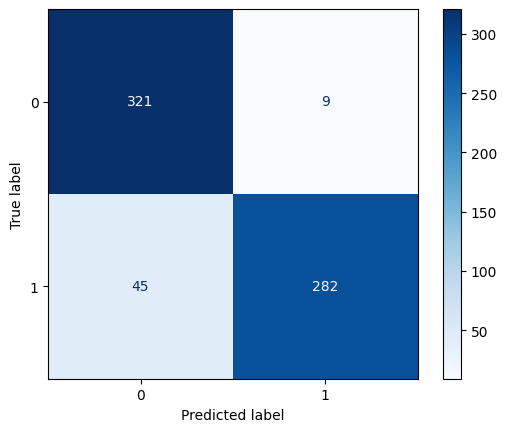

Testing XLM-R (Train=BP) on Test=MIX


Accuracy: 0.9407294832826748
F1-score: 0.9406569773491971
Precision: 0.9426069768089311
Recall: 0.9406319290465632
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       330
           1       0.97      0.91      0.94       328

    accuracy                           0.94       658
   macro avg       0.94      0.94      0.94       658
weighted avg       0.94      0.94      0.94       658



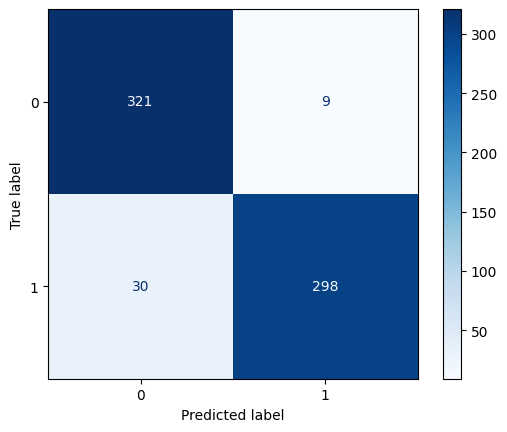

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


--- Training XLM-R on EP ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.398030,0.320430,0.939024
2,0.261010,0.284578,0.944360
3,0.181502,0.287560,0.946646


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Testing XLM-R (Train=EP) on Test=BP


Accuracy: 0.9575113808801214
F1-score: 0.9574995393403354
Precision: 0.9578263274336283
Recall: 0.9574552354284872
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       331
           1       0.97      0.95      0.96       328

    accuracy                           0.96       659
   macro avg       0.96      0.96      0.96       659
weighted avg       0.96      0.96      0.96       659



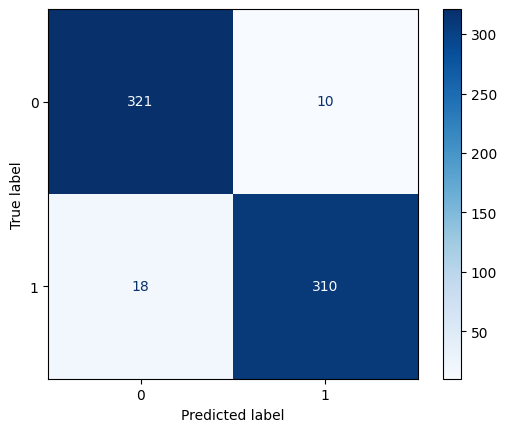

Testing XLM-R (Train=EP) on Test=EP


Accuracy: 0.9512937595129376
F1-score: 0.9512683578104139
Precision: 0.9519632414369257
Recall: 0.951209341117598
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       330
           1       0.97      0.93      0.95       327

    accuracy                           0.95       657
   macro avg       0.95      0.95      0.95       657
weighted avg       0.95      0.95      0.95       657



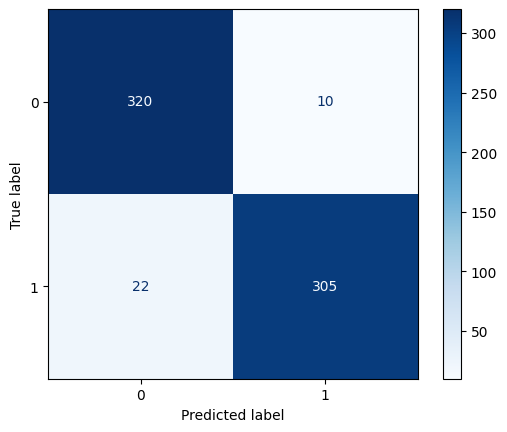

Testing XLM-R (Train=EP) on Test=MIX


Accuracy: 0.9544072948328267
F1-score: 0.9544068736141906
Precision: 0.9544068736141906
Recall: 0.9544068736141906
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       330
           1       0.95      0.95      0.95       328

    accuracy                           0.95       658
   macro avg       0.95      0.95      0.95       658
weighted avg       0.95      0.95      0.95       658



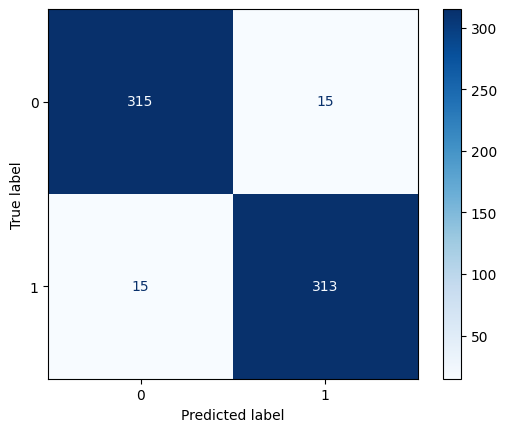

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


--- Training XLM-R on MIX ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.354115,0.294758,0.932268
2,0.238404,0.253825,0.945967
3,0.163018,0.224206,0.951294


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Testing XLM-R (Train=MIX) on Test=BP


Accuracy: 0.9590288315629742
F1-score: 0.9590227927510899
Precision: 0.9591626124133864
Recall: 0.9589934418981652
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       331
           1       0.97      0.95      0.96       328

    accuracy                           0.96       659
   macro avg       0.96      0.96      0.96       659
weighted avg       0.96      0.96      0.96       659



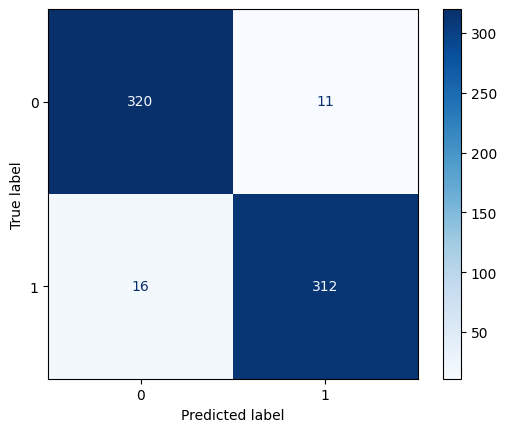

Testing XLM-R (Train=MIX) on Test=EP


Accuracy: 0.9315068493150684
F1-score: 0.9314909778495606
Precision: 0.9317368323442137
Recall: 0.931456769530164
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       330
           1       0.94      0.92      0.93       327

    accuracy                           0.93       657
   macro avg       0.93      0.93      0.93       657
weighted avg       0.93      0.93      0.93       657



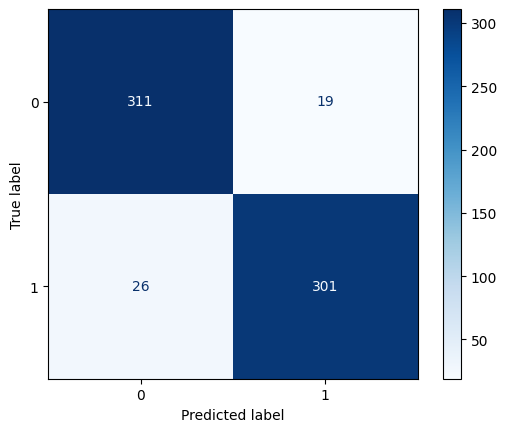

Testing XLM-R (Train=MIX) on Test=MIX


Accuracy: 0.9513677811550152
F1-score: 0.9513390092163769
Precision: 0.9522385572507777
Recall: 0.9513026607538804
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       330
           1       0.97      0.93      0.95       328

    accuracy                           0.95       658
   macro avg       0.95      0.95      0.95       658
weighted avg       0.95      0.95      0.95       658



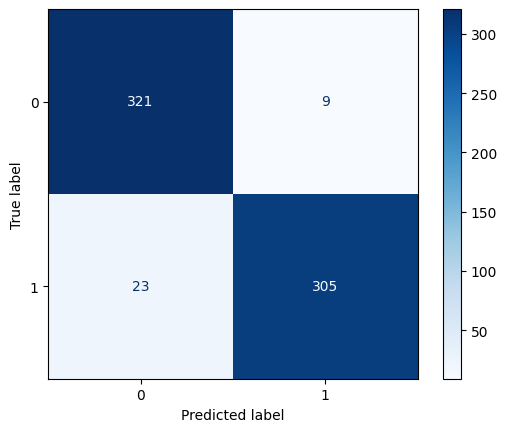

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

,Model,Train_Lang,Test_Lang,Accuracy,F1,Precision,Recall
0,Bertimbau,BP,BP,0.969651,0.969649,0.969680,0.969637
1,Bertimbau,BP,EP,0.910198,0.910034,0.912699,0.910022
2,Bertimbau,BP,MIX,0.949848,0.949828,0.950392,0.949797
3,Bertimbau,EP,BP,0.955994,0.955984,0.956239,0.955945
4,Bertimbau,EP,EP,0.946728,0.946726,0.946736,0.946719
5,Bertimbau,EP,MIX,0.963526,0.963523,0.963610,0.963507
6,Bertimbau,MIX,BP,0.969651,0.969645,0.969843,0.969609
7,Bertimbau,MIX,EP,0.952816,0.952805,0.953060,0.952766
8,Bertimbau,MIX,MIX,0.958967,0.958962,0.959092,0.958943
9,Albertina,BP,BP,0.949924,0.949920,0.949977,0.949902


In [ ]:
# configuring variables
transformer_models = {
    "Bertimbau": "neuralmind/bert-base-portuguese-cased",
    "Albertina": "PORTULAN/albertina-ptpt-base",
    "XLM-R": "xlm-roberta-base"
}

datasets = ["BP", "EP", "MIX"]
all_transformer_results = []

for model_name, model_path in transformer_models.items():
    print(f"\n{'#'*40}\nSTARTING MODEL: {model_name}\n{'#'*40}")

    # adding special tokens to the tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    tokenizer.add_tokens(["<MULTI_EXCL>", "<MULTI_QUES>", "<ELLIPSIS>"])
    tokenizer.add_tokens(emoji_tokens)

    tokenized_data = {}
    for lang in datasets:
        tokenized_data[lang] = {
            "train": Dataset(tokenizer(splits[lang]["X_train"].astype(str).tolist(), padding=True, truncation=True, max_length=128), splits[lang]["y_train"]),
            "val":   Dataset(tokenizer(splits[lang]["X_val"].astype(str).tolist(), padding=True, truncation=True, max_length=128),   splits[lang]["y_val"]),
            "test":  Dataset(tokenizer(splits[lang]["X_test"].astype(str).tolist(), padding=True, truncation=True, max_length=128),  splits[lang]["y_test"])
        }

    for train_lang in datasets:
        print(f"\n--- Training {model_name} on {train_lang} ---")

        model = AutoModelForSequenceClassification.from_pretrained(model_path, num_labels=2)
        # force the model to standard Float32 (prevents a BFloat16 overflow error encountered during the masked_fill operation)
        model = model.to(torch.float32)
        model.resize_token_embeddings(len(tokenizer))

        training_args = TrainingArguments(
                    output_dir=f"./results_{model_name}_{train_lang}",
                    eval_strategy="epoch",
                    save_strategy="epoch",
                    learning_rate=2e-5,
                    per_device_train_batch_size=8,
                    per_device_eval_batch_size=8,
                    num_train_epochs=3,
                    weight_decay=0.01,
                    load_best_model_at_end=True,
                    metric_for_best_model="accuracy",
                    save_total_limit=1,
                    report_to="none"
                )
        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=tokenized_data[train_lang]["train"],
            eval_dataset=tokenized_data[train_lang]["val"],
            compute_metrics=compute_metrics
        )

        trainer.train()

        for test_lang in datasets:
            print(f"Testing {model_name} (Train={train_lang}) on Test={test_lang}")

            res = predict_and_report_hf(trainer, tokenized_data[test_lang]["test"], display=True)

            all_transformer_results.append({
                "Model": model_name,
                "Train_Lang": train_lang,
                "Test_Lang": test_lang,
                "Accuracy": res[1],
                "F1": res[2],
                "Precision": res[3],
                "Recall": res[4]
            })

        trainer.save_model(f"./final_best_{model_name}_{train_lang}")
        tokenizer.save_pretrained(f"./final_best_{model_name}_{train_lang}")

        del model
        del trainer
        torch.cuda.empty_cache()
        gc.collect()

transformer_df = pd.DataFrame(all_transformer_results)
display(transformer_df)

Note: XLM-R models did not save during previous run, hence running the above code again:


########################################
STARTING MODEL: XLM-R
########################################

--- Training XLM-R on BP ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.291845,0.231499,0.956720
2,0.160338,0.178806,0.962035
3,0.124400,0.188116,0.964313


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Testing XLM-R (Train=BP) on Test=BP


Accuracy: 0.9620637329286799
F1-score: 0.9620605879169593
Precision: 0.9621188392445877
Recall: 0.9620422223859701
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       331
           1       0.97      0.96      0.96       328

    accuracy                           0.96       659
   macro avg       0.96      0.96      0.96       659
weighted avg       0.96      0.96      0.96       659



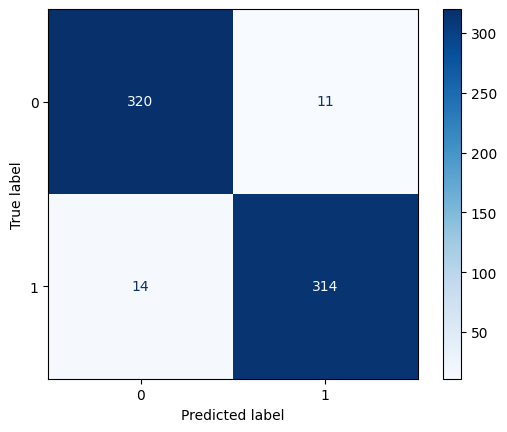

Testing XLM-R (Train=BP) on Test=EP


Accuracy: 0.9147640791476408
F1-score: 0.9146404840565723
Precision: 0.9167334202682563
Recall: 0.9146093967194885
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       330
           1       0.94      0.88      0.91       327

    accuracy                           0.91       657
   macro avg       0.92      0.91      0.91       657
weighted avg       0.92      0.91      0.91       657



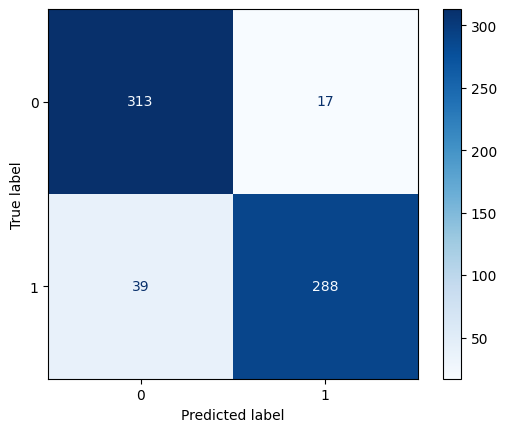

Testing XLM-R (Train=BP) on Test=MIX


Accuracy: 0.9407294832826748
F1-score: 0.9406986659395156
Precision: 0.9414642047295109
Recall: 0.9406688839615669
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       330
           1       0.96      0.92      0.94       328

    accuracy                           0.94       658
   macro avg       0.94      0.94      0.94       658
weighted avg       0.94      0.94      0.94       658



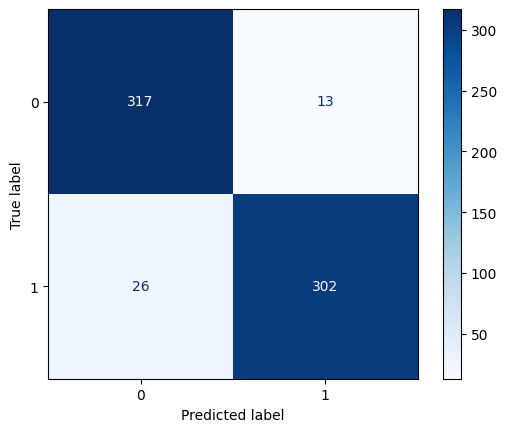

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


--- Training XLM-R on EP ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.383543,0.229503,0.942835
2,0.235248,0.296894,0.936738
3,0.166256,0.313173,0.942835


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Testing XLM-R (Train=EP) on Test=BP


Accuracy: 0.9514415781487102
F1-score: 0.9514011799410029
Precision: 0.9525973546146457
Recall: 0.9513300420013264
              precision    recall  f1-score   support

           0       0.93      0.98      0.95       331
           1       0.97      0.93      0.95       328

    accuracy                           0.95       659
   macro avg       0.95      0.95      0.95       659
weighted avg       0.95      0.95      0.95       659



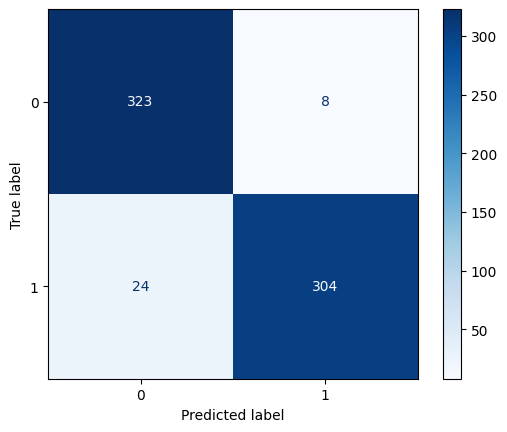

Testing XLM-R (Train=EP) on Test=EP


Accuracy: 0.9421613394216134
F1-score: 0.9420903692707367
Precision: 0.9439134481154026
Recall: 0.9420211287183764
              precision    recall  f1-score   support

           0       0.92      0.97      0.94       330
           1       0.97      0.91      0.94       327

    accuracy                           0.94       657
   macro avg       0.94      0.94      0.94       657
weighted avg       0.94      0.94      0.94       657



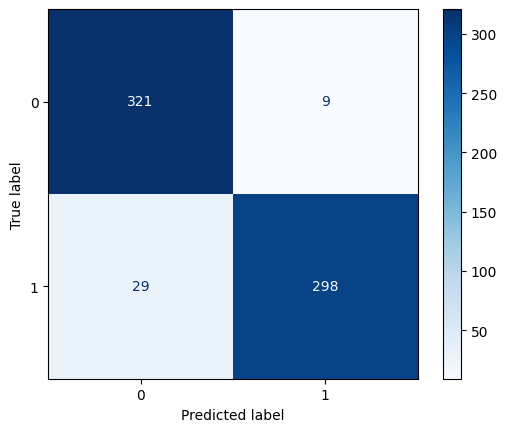

Testing XLM-R (Train=EP) on Test=MIX


Accuracy: 0.9559270516717325
F1-score: 0.9559098418419807
Precision: 0.9564789032073046
Recall: 0.9558758314855875
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       330
           1       0.97      0.94      0.96       328

    accuracy                           0.96       658
   macro avg       0.96      0.96      0.96       658
weighted avg       0.96      0.96      0.96       658



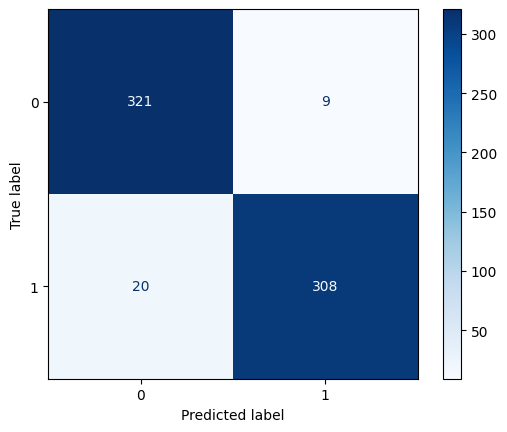

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


--- Training XLM-R on MIX ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.359952,0.256578,0.949011
2,0.230056,0.203034,0.952816
3,0.175415,0.210405,0.955860


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Testing XLM-R (Train=MIX) on Test=BP


Accuracy: 0.9635811836115327
F1-score: 0.9635623053246586
Precision: 0.9642672620585304
Recall: 0.9634975315009948
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       331
           1       0.98      0.95      0.96       328

    accuracy                           0.96       659
   macro avg       0.96      0.96      0.96       659
weighted avg       0.96      0.96      0.96       659



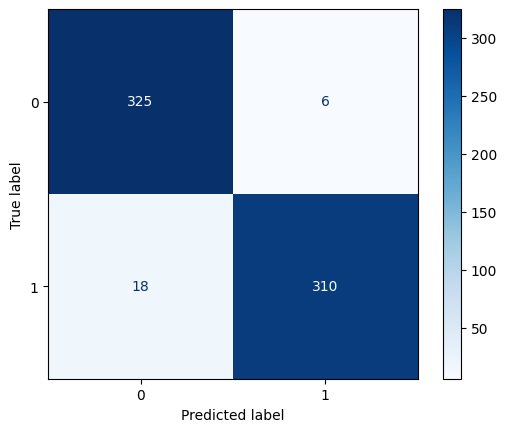

Testing XLM-R (Train=MIX) on Test=EP


Accuracy: 0.9558599695585996
F1-score: 0.9558104206046409
Precision: 0.9574991627283891
Recall: 0.9557269947178204
              precision    recall  f1-score   support

           0       0.93      0.98      0.96       330
           1       0.98      0.93      0.95       327

    accuracy                           0.96       657
   macro avg       0.96      0.96      0.96       657
weighted avg       0.96      0.96      0.96       657



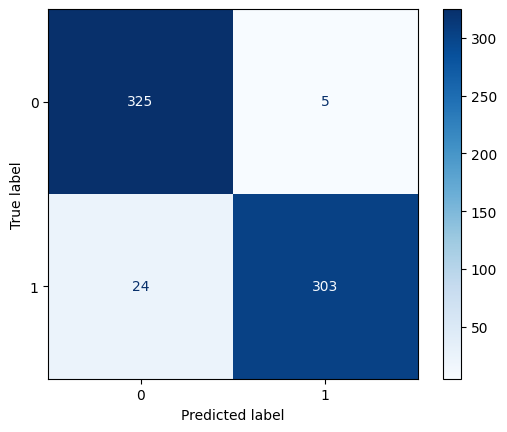

Testing XLM-R (Train=MIX) on Test=MIX


Accuracy: 0.9635258358662614
F1-score: 0.9635137008456172
Precision: 0.9639937106918239
Recall: 0.9634793052475978
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       330
           1       0.98      0.95      0.96       328

    accuracy                           0.96       658
   macro avg       0.96      0.96      0.96       658
weighted avg       0.96      0.96      0.96       658



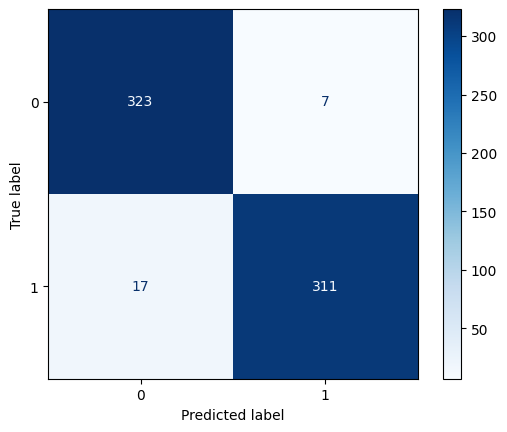

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

,Model,Train_Lang,Test_Lang,Accuracy,F1,Precision,Recall
0,XLM-R,BP,BP,0.962064,0.962061,0.962119,0.962042
1,XLM-R,BP,EP,0.914764,0.914640,0.916733,0.914609
2,XLM-R,BP,MIX,0.940729,0.940699,0.941464,0.940669
3,XLM-R,EP,BP,0.951442,0.951401,0.952597,0.951330
4,XLM-R,EP,EP,0.942161,0.942090,0.943913,0.942021
5,XLM-R,EP,MIX,0.955927,0.955910,0.956479,0.955876
6,XLM-R,MIX,BP,0.963581,0.963562,0.964267,0.963498
7,XLM-R,MIX,EP,0.955860,0.955810,0.957499,0.955727
8,XLM-R,MIX,MIX,0.963526,0.963514,0.963994,0.963479


In [ ]:
transformer_models = {
    "XLM-R": "xlm-roberta-base"
}

datasets = ["BP", "EP", "MIX"]
all_transformer_results = []

for model_name, model_path in transformer_models.items():
    print(f"\n{'#'*40}\nSTARTING MODEL: {model_name}\n{'#'*40}")

    tokenizer = AutoTokenizer.from_pretrained(model_path)
    tokenizer.add_tokens(["<MULTI_EXCL>", "<MULTI_QUES>", "<ELLIPSIS>"])
    tokenizer.add_tokens(emoji_tokens)

    tokenized_data = {}
    for lang in datasets:
        tokenized_data[lang] = {
            "train": Dataset(tokenizer(splits[lang]["X_train"].astype(str).tolist(), padding=True, truncation=True, max_length=128), splits[lang]["y_train"]),
            "val":   Dataset(tokenizer(splits[lang]["X_val"].astype(str).tolist(), padding=True, truncation=True, max_length=128),   splits[lang]["y_val"]),
            "test":  Dataset(tokenizer(splits[lang]["X_test"].astype(str).tolist(), padding=True, truncation=True, max_length=128),  splits[lang]["y_test"])
        }

    for train_lang in datasets:
        print(f"\n--- Training {model_name} on {train_lang} ---")

        model = AutoModelForSequenceClassification.from_pretrained(model_path, num_labels=2)
        model = model.to(torch.float32)
        model.resize_token_embeddings(len(tokenizer))

        training_args = TrainingArguments(
                    output_dir=f"./results_{model_name}_{train_lang}",
                    eval_strategy="epoch",
                    save_strategy="epoch",
                    learning_rate=2e-5,
                    per_device_train_batch_size=8,
                    per_device_eval_batch_size=8,
                    num_train_epochs=3,
                    weight_decay=0.01,
                    load_best_model_at_end=True,
                    metric_for_best_model="accuracy",
                    save_total_limit=1,
                    report_to="none"
                )
        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=tokenized_data[train_lang]["train"],
            eval_dataset=tokenized_data[train_lang]["val"],
            compute_metrics=compute_metrics
        )

        trainer.train()

        for test_lang in datasets:
            print(f"Testing {model_name} (Train={train_lang}) on Test={test_lang}")

            res = predict_and_report_hf(trainer, tokenized_data[test_lang]["test"], display=True)

            all_transformer_results.append({
                "Model": model_name,
                "Train_Lang": train_lang,
                "Test_Lang": test_lang,
                "Accuracy": res[1],
                "F1": res[2],
                "Precision": res[3],
                "Recall": res[4]
            })

        trainer.save_model(f"./final_best_{model_name}_{train_lang}")
        tokenizer.save_pretrained(f"./final_best_{model_name}_{train_lang}")

        del model
        del trainer
        torch.cuda.empty_cache()
        gc.collect()

transformer_df = pd.DataFrame(all_transformer_results)
display(transformer_df)

#4. Dialect Classification

In [ ]:
print(f"Total errors: {len(cross_eval_records)}")
# removing identical review/lang/direction combinations
cross_eval_records = list(set(cross_eval_records))
print(f"Unique errors: {len(cross_eval_records)}")

Total errors: 420
Unique errors: 235


In [ ]:
pattern = r"<ELLIPSIS>|<MULTI_EXCL>|<MULTI_QUES>|:[^:]*:"

def clean_text(text):
    text = re.sub(pattern, "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


model_path = hf_hub_download(
    repo_id="duarteocarmo/fasttext-euptvid",
    filename="model.bin"
)

model = fasttext.load_model(model_path)

# cleaning before model input
cleaned_records = [
    (clean_text(text), dataset, direction, true, pred)
    for text, dataset, direction, true, pred in cross_eval_records
]

# running dialect predictions
labels, probs = model.predict(texts)

# building the output
rows = []
for (cleaned_text, dataset, direction, true, pred), label, prob in zip(cleaned_records, labels, probs):
    # cleaning the fasttext label
    clean_label = label[0].replace("__label__", "")

    rows.append({
        "text": cleaned_text,
        "true_dialect": dataset,
        "predicted_dialect": clean_label,
        "transfer_direction": direction,
        "true_sentiment_label": true,
        "predicted_sentiment_label": pred,
        "confidence": prob[0]
    })

df = pd.DataFrame(rows)
df.to_excel("misclassified_analysis.xlsx", index=False)

model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]